In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import pearsonr, jarque_bera, probplot, gaussian_kde
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

In [76]:
base_path = Path(os.getcwd())
models_path = Path("../../Models")
 
CRISIS_START = "2021-10-01"
CRISIS_END   = "2023-06-30"

# Dataframe formating

In [77]:
# STEP 0 — Load hourly data
# ─────────────────────────────────────────────────────────────────────────────
 
# ── energy prices ─────────────────────────────────────────────────────────────
input_path  = base_path / r"..\..\Data\Cleaned\df_energy_cleaned.parquet"
df_price = pd.read_parquet(input_path)
df_price["datetime"] = pd.to_datetime(df_price["datetime"])
df_price["date"]     = pd.to_datetime(df_price["date"])
 
# keep only clean hours
clean_mask = (df_price["zero_flag"] == 0) & (df_price["imputed_flag"] == 0)
df_price   = df_price[clean_mask].copy()
 
print("── Step 0: Data loaded ───────────────────────────────────────────")
print(f"  Price rows (clean): {len(df_price)}")
print(f"  Price range: {df_price['datetime'].min().date()} → "
      f"{df_price['datetime'].max().date()}")
print(f"  Price stats: mean={df_price['price_NORD_EURMWh'].mean():.1f}  "
      f"std={df_price['price_NORD_EURMWh'].std():.1f}  "
      f"min={df_price['price_NORD_EURMWh'].min():.1f}  "
      f"max={df_price['price_NORD_EURMWh'].max():.1f} EUR/MWh")

── Step 0: Data loaded ───────────────────────────────────────────
  Price rows (clean): 185970
  Price range: 2005-01-01 → 2026-03-22
  Price stats: mean=83.6  std=69.8  min=0.0  max=871.0 EUR/MWh


In [78]:
# ── weather / GHI ─────────────────────────────────────────────────────────────
df_weather = pd.read_parquet(base_path / r"..\..\Data\Cleaned\df_bologna_cleaned.parquet")
df_weather["datetime"] = pd.to_datetime(df_weather["time"])
df_weather["date"]     = df_weather["datetime"].dt.normalize()
 
print(f"\n  Weather rows: {len(df_weather)}")
print(f"  Weather range: {df_weather['datetime'].min().date()} → "
      f"{df_weather['datetime'].max().date()}")
print(f"  GHI columns available: {[c for c in df_weather.columns if 'GHI' in c or 'ghi' in c.lower()]}")


  Weather rows: 184079
  Weather range: 2005-01-01 → 2025-12-31
  GHI columns available: ['CLEAR_SKY_GHI', 'GHI', 'GHI_index']


In [79]:
# ── align on common hourly timestamp ─────────────────────────────────────────
# round both to the hour to ensure alignment
df_price["hour_ts"]   = df_price["datetime"].dt.floor("h")
df_weather["hour_ts"] = df_weather["datetime"].dt.floor("h")
 
df_hourly = df_price[["hour_ts", "date", "price_NORD_EURMWh"]].merge(
    df_weather[["hour_ts", "GHI", "CLEAR_SKY_GHI", "t2m"]],
    on="hour_ts", how="inner"
)
 
df_hourly["year"]    = df_hourly["hour_ts"].dt.year
df_hourly["month"]   = df_hourly["hour_ts"].dt.month
df_hourly["hour"]    = df_hourly["hour_ts"].dt.hour
df_hourly["quarter"] = df_hourly["hour_ts"].dt.quarter

In [80]:
# crisis flag
df_hourly["crisis"] = (
    (df_hourly["date"] >= CRISIS_START) &
    (df_hourly["date"] <= CRISIS_END)
).astype(int)
 
# daylight filter: GHI > 0 (solar is producing)
df_daylight = df_hourly[df_hourly["GHI"] > 0].copy()
 
print(f"\n  Merged hourly rows : {len(df_hourly)}")
print(f"  Daylight hours     : {len(df_daylight)}")
print(f"  GHI range (daylight): [{df_daylight['GHI'].min():.1f}, "
      f"{df_daylight['GHI'].max():.1f}] W/m²")


  Merged hourly rows : 184025
  Daylight hours     : 99999
  GHI range (daylight): [0.0, 993.4] W/m²


In [81]:
# Compute daily capture price
# ─────────────────────────────────────────────────────────────────────────────
# CP(t) = Σₕ P(h)·GHI(h) / Σₕ GHI(h)   [daylight hours only]
 
daily_cp = (
    df_daylight
    .groupby("date")
    .apply(lambda g: pd.Series({
        "capture_price": (g["price_NORD_EURMWh"] * g["GHI"]).sum() / g["GHI"].sum(),
        "ghi_sum":        g["GHI"].sum(),
        "ghi_cs_sum":     g["CLEAR_SKY_GHI"].sum(),
        "n_daylight_hrs": len(g),
    }))
    .reset_index()
)

In [82]:
daily_cp

,date,capture_price,ghi_sum,ghi_cs_sum,n_daylight_hrs
0,2005-01-01,22.843490,833.359338,833.359338,5.0
1,2005-01-02,34.598030,1982.049556,2032.770931,10.0
2,2005-01-03,80.729109,1879.852110,1921.520051,10.0
3,2005-01-04,80.186901,2037.694044,2125.667418,10.0
4,2005-01-05,83.087721,1963.360307,2099.169946,10.0
...,...,...,...,...,...
7665,2025-12-27,83.563581,2055.588290,2076.590182,10.0
7666,2025-12-28,84.766353,2122.258604,2124.960890,10.0
7667,2025-12-29,106.968811,2068.760437,2086.895966,10.0
7668,2025-12-30,104.908892,1326.291826,1951.388265,10.0


In [83]:
# daily mean price (all clean hours including night)
daily_mean = (
    df_hourly
    .groupby("date")["price_NORD_EURMWh"]
    .mean()
    .rename("market_price")
    .reset_index()
)

In [84]:
# daily off-peak price: hours 0–6 and 22–23
off_peak_mask = df_hourly["hour"].isin([0,1,2,3,4,5,6,22,23])
daily_offpeak = (
    df_hourly[off_peak_mask]
    .groupby("date")["price_NORD_EURMWh"]
    .mean()
    .rename("offpeak_price")
    .reset_index()
)

In [85]:
# daily peak price: hours 8–20
peak_mask = df_hourly["hour"].isin(range(8, 21))
daily_peak = (
    df_hourly[peak_mask]
    .groupby("date")["price_NORD_EURMWh"]
    .mean()
    .rename("peak_price")
    .reset_index()
)

In [86]:
# merge all
df_daily = (
    daily_cp
    .merge(daily_mean,   on="date", how="left")
    .merge(daily_offpeak, on="date", how="left")
    .merge(daily_peak,    on="date", how="left")
)
 
df_daily["date"]     = pd.to_datetime(df_daily["date"])
df_daily["year"]     = df_daily["date"].dt.year
df_daily["month"]    = df_daily["date"].dt.month
df_daily["quarter"]  = df_daily["date"].dt.quarter
df_daily["crisis"]   = (
    (df_daily["date"] >= CRISIS_START) &
    (df_daily["date"] <= CRISIS_END)
).astype(int)
df_daily["KT_daily"] = (
    df_daily["ghi_sum"] / df_daily["ghi_cs_sum"].clip(lower=1.0)
).clip(0, 1)
 
print("\n── Step 1: Daily capture price ─────────────────────────────────")
print(f"  Days computed: {len(df_daily)}")
print(f"  Capture price: mean={df_daily['capture_price'].mean():.2f}  "
      f"std={df_daily['capture_price'].std():.2f} EUR/MWh")
print(f"  Market price : mean={df_daily['market_price'].mean():.2f}  "
      f"std={df_daily['market_price'].std():.2f} EUR/MWh")


── Step 1: Daily capture price ─────────────────────────────────
  Days computed: 7670
  Capture price: mean=87.19  std=67.43 EUR/MWh
  Market price : mean=83.11  std=66.41 EUR/MWh


In [87]:
# Capture rate and cannibalisation discount
# ─────────────────────────────────────────────────────────────────────────────
 
df_daily["capture_rate"]   = (
    df_daily["capture_price"] / df_daily["market_price"]
)
df_daily["cannib_discount"] = (
    df_daily["market_price"] - df_daily["capture_price"]
)
 
# exclude crisis and outliers for clean statistics
clean = df_daily[
    (df_daily["crisis"] == 0) &
    df_daily["capture_rate"].notna() &
    (df_daily["capture_rate"] > 0) &
    (df_daily["capture_rate"] < 3)
].copy()
 
print("\n── Step 2: Capture rate ─────────────────────────────────────────")
print(f"  Capture rate (excl. crisis):")
print(f"    mean  = {clean['capture_rate'].mean():.4f}")
print(f"    std   = {clean['capture_rate'].std():.4f}")
print(f"    p10   = {clean['capture_rate'].quantile(0.10):.4f}")
print(f"    p50   = {clean['capture_rate'].quantile(0.50):.4f}")
print(f"    p90   = {clean['capture_rate'].quantile(0.90):.4f}")
print(f"\n  Mean cannibalisation discount: "
      f"{clean['cannib_discount'].mean():.2f} EUR/MWh")
print(f"  Days with capture_rate < 1 (solar discount): "
      f"{(clean['capture_rate'] < 1).mean()*100:.1f}%")


── Step 2: Capture rate ─────────────────────────────────────────
  Capture rate (excl. crisis):
    mean  = 1.0654
    std   = 0.1613
    p10   = 0.9120
    p50   = 1.0492
    p90   = 1.2846

  Mean cannibalisation discount: -4.56 EUR/MWh
  Days with capture_rate < 1 (solar discount): 31.2%


In [88]:
df_daily.columns

Index(['date', 'capture_price', 'ghi_sum', 'ghi_cs_sum', 'n_daylight_hrs',
       'market_price', 'offpeak_price', 'peak_price', 'year', 'month',
       'quarter', 'crisis', 'KT_daily', 'capture_rate', 'cannib_discount'],
      dtype='str')

# Descriptive analysis


── Step 3: Annual capture rate ──────────────────────────────────
  Year       CP       MP       CR   Discount      KT
  2005    74.43    57.71   1.2684     -16.72  0.7342
  2006    92.42    73.63   1.2399     -18.79  0.7684
  2007    87.17    68.48   1.2616     -18.69  0.7677
  2008    99.58    82.92   1.1923     -16.66  0.7325
  2009    74.43    60.83   1.2185     -13.60  0.7292
  2010    69.55    61.98   1.1166      -7.56  0.6939
  2011    74.43    70.18   1.0611      -4.25  0.7912
  2012    73.75    74.05   0.9907      +0.30  0.7626
  2013    60.89    61.61   0.9768      +0.72  0.7137
  2014    50.80    50.35   0.9952      -0.44  0.7108
  2015    54.38    52.71   1.0249      -1.67  0.7679
  2016    44.53    42.67   1.0363      -1.86  0.7286
  2017    56.29    54.41   1.0225      -1.88  0.7958
  2018    62.28    60.71   1.0218      -1.57  0.7334
  2019    52.38    51.25   1.0180      -1.12  0.7665
  2020    38.51    37.80   0.9937      -0.71  0.7853
  2021    85.93    85.10   1.007

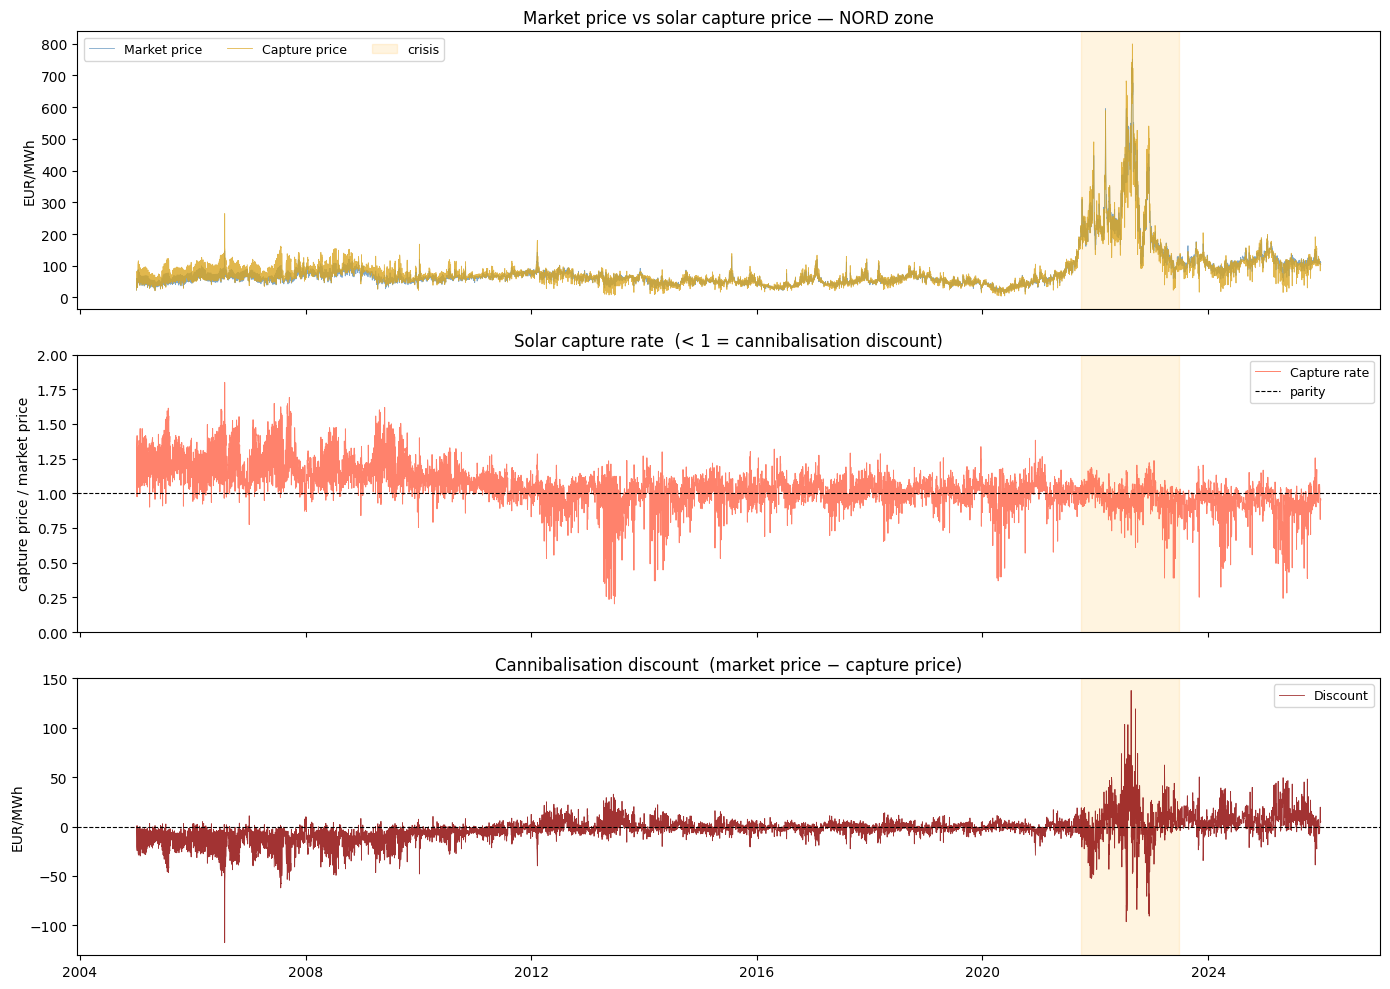

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
 
print("\n── Step 3: Annual capture rate ──────────────────────────────────")
print(f"  {'Year':>4}  {'CP':>7}  {'MP':>7}  {'CR':>7}  "
      f"{'Discount':>9}  {'KT':>6}")
 
annual = (
    clean.groupby("year")
    .agg(
        cp        = ("capture_price",  "mean"),
        mp        = ("market_price",   "mean"),
        cr        = ("capture_rate",   "mean"),
        discount  = ("cannib_discount","mean"),
        kt        = ("KT_daily",       "mean"),
        n         = ("capture_rate",   "count"),
    )
    .reset_index()
)
 
for _, row in annual.iterrows():
    print(f"  {int(row.year):>4}  {row.cp:>7.2f}  {row.mp:>7.2f}  "
          f"{row.cr:>7.4f}  {row.discount:>+9.2f}  {row.kt:>6.4f}")
 
# ── figure 1: capture price and market price over time ───────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
 
axes[0].plot(df_daily["date"], df_daily["market_price"],
             lw=0.6, color="steelblue", alpha=0.7, label="Market price")
axes[0].plot(df_daily["date"], df_daily["capture_price"],
             lw=0.6, color="goldenrod", alpha=0.8, label="Capture price")
axes[0].axvspan(pd.Timestamp(CRISIS_START), pd.Timestamp(CRISIS_END),
                alpha=0.12, color="orange", label="crisis")
axes[0].set_ylabel("EUR/MWh")
axes[0].legend(fontsize=9, ncol=3)
axes[0].set_title("Market price vs solar capture price — NORD zone")
 
axes[1].plot(df_daily["date"], df_daily["capture_rate"],
             lw=0.7, color="tomato", alpha=0.8, label="Capture rate")
axes[1].axhline(1.0, color="black", lw=0.8, ls="--", label="parity")
axes[1].axvspan(pd.Timestamp(CRISIS_START), pd.Timestamp(CRISIS_END),
                alpha=0.12, color="orange")
axes[1].set_ylabel("capture price / market price")
axes[1].set_ylim(0, 2)
axes[1].legend(fontsize=9)
axes[1].set_title("Solar capture rate  (< 1 = cannibalisation discount)")
 
axes[2].plot(df_daily["date"], df_daily["cannib_discount"],
             lw=0.6, color="darkred", alpha=0.8, label="Discount")
axes[2].axhline(0, color="black", lw=0.8, ls="--")
axes[2].axvspan(pd.Timestamp(CRISIS_START), pd.Timestamp(CRISIS_END),
                alpha=0.12, color="orange")
axes[2].set_ylabel("EUR/MWh")
axes[2].legend(fontsize=9)
axes[2].set_title("Cannibalisation discount  (market price − capture price)")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
plt.tight_layout()
plt.show()

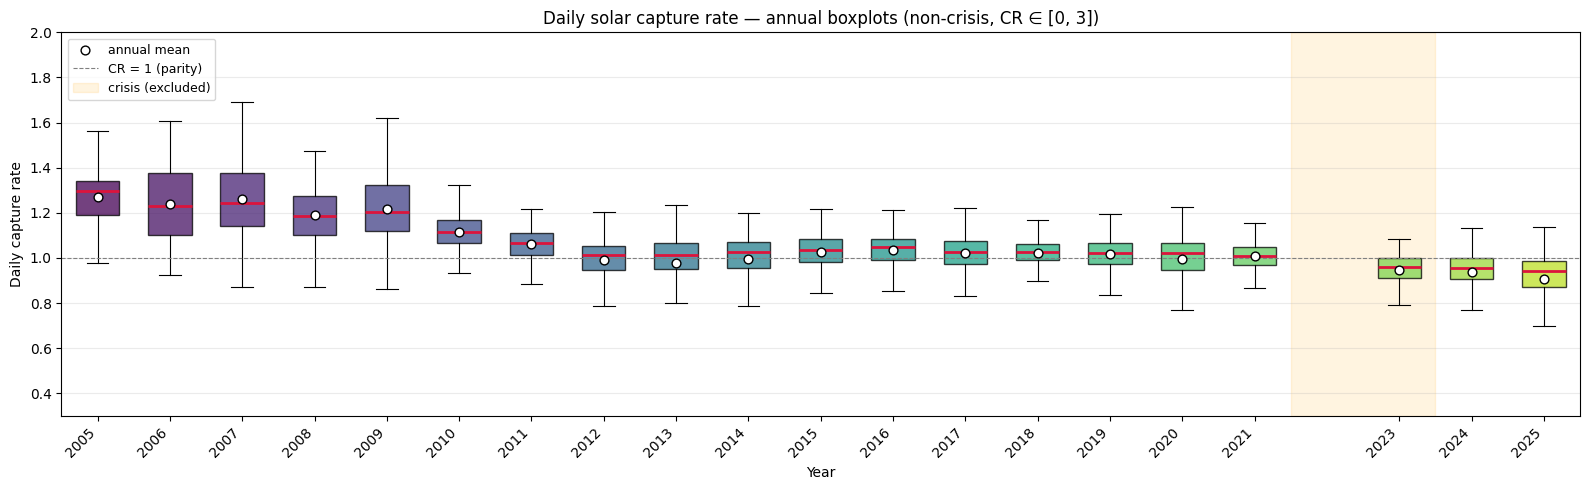

In [90]:
# ── Boxplot of daily capture rate by year ────────────────────────────────────

df_box = df_daily[
    df_daily["capture_rate"].between(0, 3) &
    (df_daily["crisis"] == 0)
].copy()

years_sorted = sorted(df_box["year"].unique())
data_by_year = [df_box.loc[df_box["year"] == y, "capture_rate"].values
                for y in years_sorted]

fig, ax = plt.subplots(figsize=(16, 5))

bp = ax.boxplot(
    data_by_year,
    positions=years_sorted,
    widths=0.6,
    patch_artist=True,
    showfliers=False,          # hide outliers for clarity
    medianprops=dict(color="crimson", lw=2),
    whiskerprops=dict(lw=0.8),
    capprops=dict(lw=0.8),
)

# colour boxes by 5-year period
period_colors = plt.cm.viridis(np.linspace(0, 0.9, len(years_sorted)))
for patch, color in zip(bp["boxes"], period_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# annual mean dots
annual_means = [df_box.loc[df_box["year"] == y, "capture_rate"].mean()
                for y in years_sorted]
ax.scatter(years_sorted, annual_means, color="white", edgecolors="black",
           s=40, zorder=5, label="annual mean")

# reference lines
ax.axhline(1.0, color="grey", lw=0.8, ls="--", label="CR = 1 (parity)")

# shade crisis period
ax.axvspan(2021.5, 2023.5, alpha=0.12, color="orange", label="crisis (excluded)")

ax.set_xlabel("Year")
ax.set_ylabel("Daily capture rate")
ax.set_ylim(0.3, 2.0)
ax.set_xticks(years_sorted)
ax.set_xticklabels(years_sorted, rotation=45, ha="right")
ax.set_title("Daily solar capture rate — annual boxplots (non-crisis, CR ∈ [0, 3])")
ax.legend(fontsize=9)
ax.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()


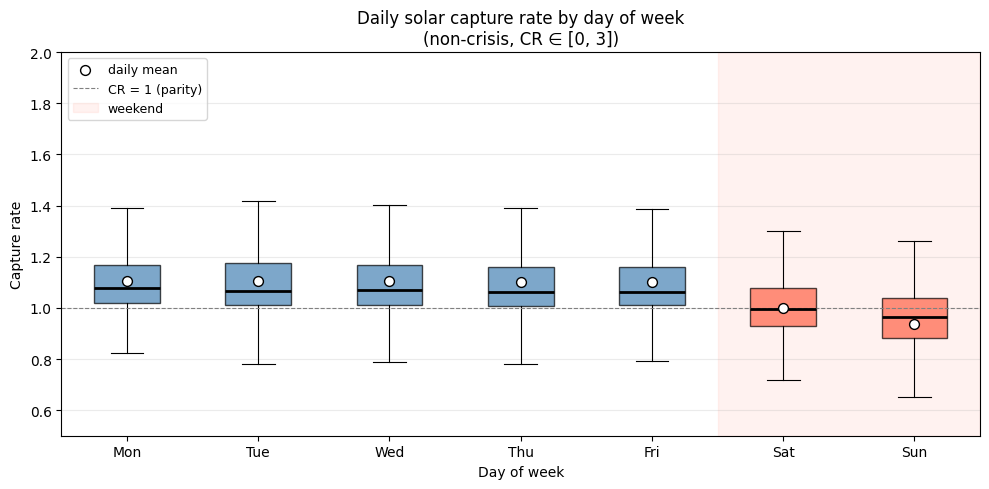


── CR by day of week ────────────────────────────────────────────────
  Day               n    mean   median     std
  Mon            1005  1.1060   1.0794  0.1438
  Tue            1005  1.1067   1.0678  0.1493
  Wed            1005  1.1051   1.0693  0.1516
  Thu            1004  1.1012   1.0633  0.1504
  Fri            1003  1.1012   1.0633  0.1478
  Sat            1005  1.0004   0.9962  0.1305
  Sun            1005  0.9374   0.9643  0.1636


In [91]:
# ── Boxplot of daily capture rate by day of week ─────────────────────────────

df_dow = df_daily[
    df_daily["capture_rate"].between(0, 3) &
    (df_daily["crisis"] == 0)
].copy()

df_dow["weekday"]     = df_dow["date"].dt.dayofweek        # 0=Mon … 6=Sun
df_dow["weekday_name"] = df_dow["date"].dt.day_name()

day_order  = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
colors     = ["steelblue"] * 5 + ["tomato"] * 2    # weekday / weekend

data_by_day = [df_dow.loc[df_dow["weekday_name"] == d, "capture_rate"].values
               for d in day_order]

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(
    data_by_day,
    labels=day_labels,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", lw=2),
    whiskerprops=dict(lw=0.8),
    capprops=dict(lw=0.8),
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# daily means
means = [df_dow.loc[df_dow["weekday_name"] == d, "capture_rate"].mean()
         for d in day_order]
ax.scatter(range(1, 8), means, color="white", edgecolors="black",
           s=50, zorder=5, label="daily mean")

ax.axhline(1.0, color="grey", lw=0.8, ls="--", label="CR = 1 (parity)")
ax.axvspan(5.5, 7.5, alpha=0.08, color="tomato", label="weekend")

ax.set_xlabel("Day of week")
ax.set_ylabel("Capture rate")
ax.set_ylim(0.5, 2.0)
ax.set_title("Daily solar capture rate by day of week\n(non-crisis, CR ∈ [0, 3])")
ax.legend(fontsize=9)
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

# summary
print(f"\n── CR by day of week ────────────────────────────────────────────────")
print(f"  {'Day':<12} {'n':>6} {'mean':>7} {'median':>8} {'std':>7}")
for d, label in zip(day_order, day_labels):
    s = df_dow.loc[df_dow["weekday_name"] == d, "capture_rate"]
    print(f"  {label:<12} {len(s):>6} {s.mean():>7.4f} {s.median():>8.4f} {s.std():>7.4f}")


── Kruskal-Wallis (overall) ──────────────────────────────────────────
  H=1059.6344  p=8.0041e-231  *** significant

── Pairwise tests (Bonferroni α=0.0167) ────────────────────
  Pair                   Mann-Whitney U     p-value    sig   KS stat        KS p
  Weekday vs Saturday         3534057.0  1.3854e-89    ***    0.3157  1.8636e-74
  Weekday vs Sunday           3960354.0  4.3074e-179    ***    0.4267  4.5871e-138
  Saturday vs Sunday           604701.0  1.8258e-14    ***    0.1264  2.0700e-07

── Group descriptives ────────────────────────────────────────────────
  Group             n    mean   median     std     p25     p75
  Weekday        5022  1.1041   1.0687  0.1485  1.0117  1.1678
  Saturday       1005  1.0004   0.9962  0.1304  0.9278  1.0780
  Sunday         1005  0.9374   0.9643  0.1635  0.8834  1.0373


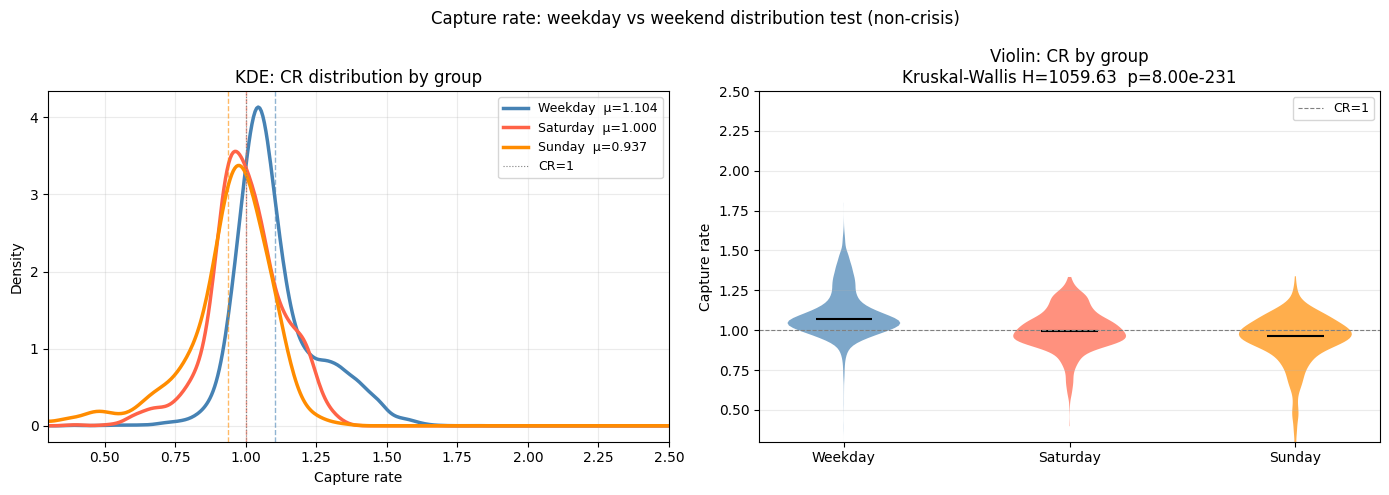

In [92]:
# ── Statistical test: CR distribution weekday vs Saturday vs Sunday ───────────
from scipy.stats import kruskal, mannwhitneyu, ks_2samp

df_dow = df_daily[
    df_daily["capture_rate"].between(0, 3) &
    (df_daily["crisis"] == 0)
].copy()
df_dow["weekday_name"] = df_dow["date"].dt.day_name()

cr_weekday = df_dow.loc[df_dow["weekday_name"].isin(
    ["Monday","Tuesday","Wednesday","Thursday","Friday"]), "capture_rate"].values
cr_saturday = df_dow.loc[df_dow["weekday_name"] == "Saturday", "capture_rate"].values
cr_sunday   = df_dow.loc[df_dow["weekday_name"] == "Sunday",   "capture_rate"].values

# ── 1. Kruskal-Wallis: any difference across the 3 groups? ───────────────────
kw_stat, kw_p = kruskal(cr_weekday, cr_saturday, cr_sunday)

# ── 2. Pairwise Mann-Whitney U (with Bonferroni correction, 3 pairs) ─────────
pairs = [
    ("Weekday", "Saturday", cr_weekday,  cr_saturday),
    ("Weekday", "Sunday",   cr_weekday,  cr_sunday),
    ("Saturday","Sunday",   cr_saturday, cr_sunday),
]
alpha_bonf = 0.05 / len(pairs)

mw_results = []
for a_name, b_name, a, b in pairs:
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    ks_stat, ks_p = ks_2samp(a, b)
    mw_results.append((a_name, b_name, stat, p, ks_stat, ks_p))

# ── 3. Print results ──────────────────────────────────────────────────────────
print("── Kruskal-Wallis (overall) ──────────────────────────────────────────")
print(f"  H={kw_stat:.4f}  p={kw_p:.4e}  "
      f"{'*** significant' if kw_p < 0.001 else '** significant' if kw_p < 0.01 else 'n.s.'}")

print(f"\n── Pairwise tests (Bonferroni α={alpha_bonf:.4f}) ────────────────────")
print(f"  {'Pair':<22} {'Mann-Whitney U':>14}  {'p-value':>10}  {'sig':>5}  "
      f"{'KS stat':>8}  {'KS p':>10}")
for a_name, b_name, stat, p, ks_stat, ks_p in mw_results:
    sig = "***" if p < alpha_bonf/10 else "**" if p < alpha_bonf else "*" if p < 0.05 else "n.s."
    print(f"  {a_name+' vs '+b_name:<22} {stat:>14.1f}  {p:>10.4e}  {sig:>5}  "
          f"{ks_stat:>8.4f}  {ks_p:>10.4e}")

print(f"\n── Group descriptives ────────────────────────────────────────────────")
print(f"  {'Group':<12} {'n':>6} {'mean':>7} {'median':>8} {'std':>7} {'p25':>7} {'p75':>7}")
for name, arr in [("Weekday", cr_weekday), ("Saturday", cr_saturday), ("Sunday", cr_sunday)]:
    print(f"  {name:<12} {len(arr):>6} {arr.mean():>7.4f} {np.median(arr):>8.4f} "
          f"{arr.std():>7.4f} {np.percentile(arr,25):>7.4f} {np.percentile(arr,75):>7.4f}")

# ── 4. Plot: KDE overlay for the 3 groups ────────────────────────────────────
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_grid = np.linspace(0.3, 2.5, 400)
for name, arr, color in [("Weekday", cr_weekday, "steelblue"),
                          ("Saturday", cr_saturday, "tomato"),
                          ("Sunday",   cr_sunday,   "darkorange")]:
    kde = gaussian_kde(arr)
    axes[0].plot(x_grid, kde(x_grid), lw=2.5, color=color,
                 label=f"{name}  μ={arr.mean():.3f}")
    axes[0].axvline(arr.mean(), color=color, lw=1, ls="--", alpha=0.6)

axes[0].axvline(1.0, color="grey", lw=0.8, ls=":", label="CR=1")
axes[0].set_xlabel("Capture rate")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0.3, 2.5)
axes[0].set_title("KDE: CR distribution by group")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

# violin plot
parts = axes[1].violinplot(
    [cr_weekday, cr_saturday, cr_sunday],
    positions=[1, 2, 3],
    showmedians=True,
    showextrema=False,
)
colors_v = ["steelblue", "tomato", "darkorange"]
for pc, color in zip(parts["bodies"], colors_v):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")

axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(["Weekday", "Saturday", "Sunday"])
axes[1].axhline(1.0, color="grey", lw=0.8, ls="--", label="CR=1")
axes[1].set_ylabel("Capture rate")
axes[1].set_ylim(0.3, 2.5)
axes[1].set_title(f"Violin: CR by group\n"
                  f"Kruskal-Wallis H={kw_stat:.2f}  p={kw_p:.2e}")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25, axis="y")

plt.suptitle("Capture rate: weekday vs weekend distribution test (non-crisis)",
             fontsize=12)
plt.tight_layout()
plt.show()



── Step 4: Cannibalisation vs penetration ───────────────────────
  Rolling corr(capture_rate, penetration_index): r=-0.9506  p=0.0000  *** cannibalisation confirmed
  OLS: capture_rate = 1.2203 -0.2976·pen_index
  At pen=1.0 (2024): 0.9227
  At pen=1.5 (2027): 0.7740
  At pen=2.0 (2030): 0.6252


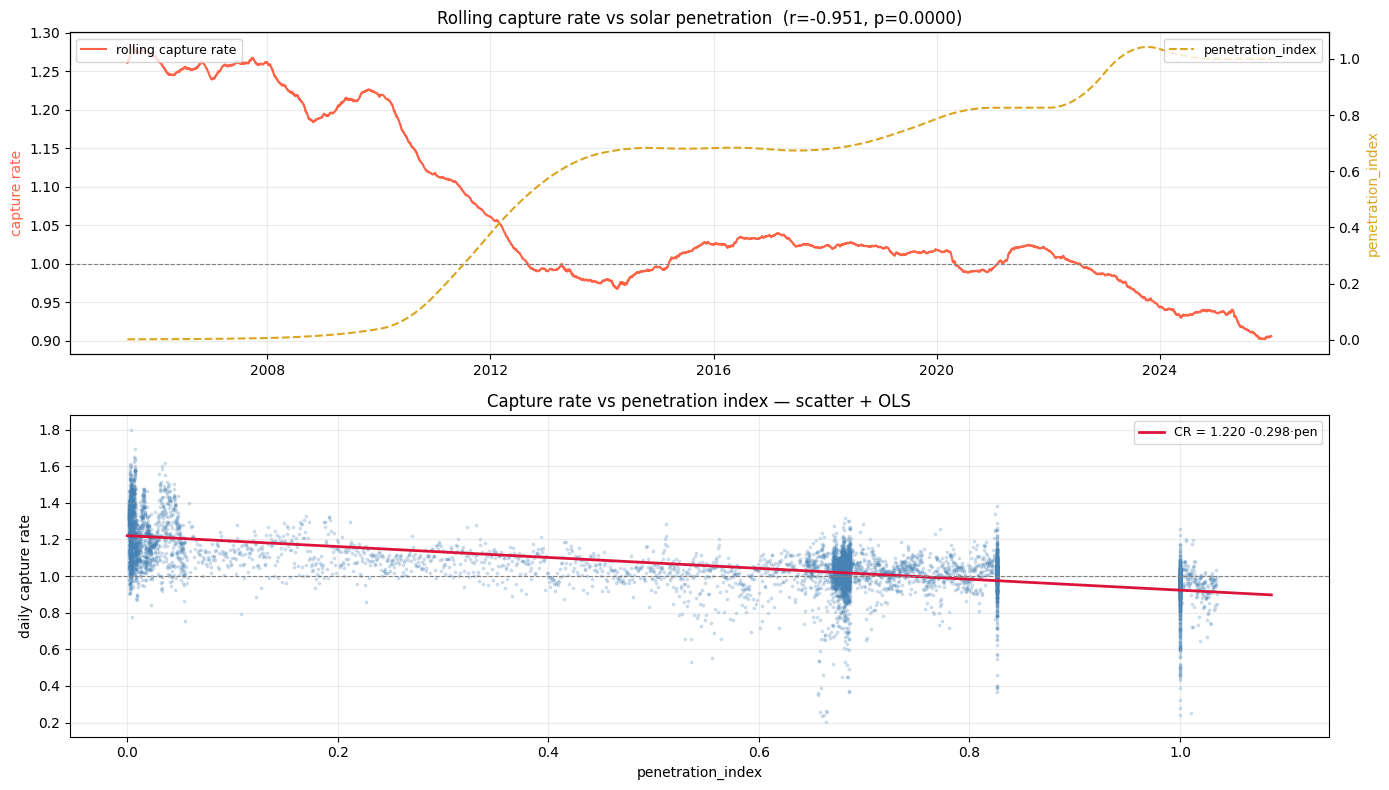

In [93]:
# Cannibalisation effect over time
# ─────────────────────────────────────────────────────────────────────────────

# rebuild penetration_index from annual solar share
solar_share_pct = {
    2005:0.02,2006:0.03,2007:0.05,2008:0.10,2009:0.26,2010:0.63,
    2011:3.00,2012:5.70,2013:7.40,2014:7.90,2015:7.80,2016:7.90,
    2017:7.70,2018:7.90,2019:8.60,2020:9.50,2021:9.50,2022:9.50,
    2023:12.30,2024:11.50,
}
REFERENCE_SHARE = 11.5

lookup_years = np.array(sorted(solar_share_pct) + [2025], dtype=float)
lookup_vals  = np.array(
    [solar_share_pct[yr]/REFERENCE_SHARE for yr in sorted(solar_share_pct)]
    + [solar_share_pct[2024]/REFERENCE_SHARE], dtype=float
)

doy = df_daily["date"].dt.dayofyear
df_daily["decimal_year"]      = df_daily["year"].astype(float) + (doy - 1) / 365.0
df_daily["penetration_index"] = np.interp(
    df_daily["decimal_year"], lookup_years, lookup_vals
)

# rolling 365-day means — keep date as index
WINDOW   = 365
roll_cr  = df_daily.set_index("date")["capture_rate"].rolling(WINDOW, min_periods=180).mean()
roll_pen = df_daily.set_index("date")["penetration_index"].rolling(WINDOW, min_periods=180).mean()

# align before correlation
aligned  = pd.concat([roll_cr.rename("cr"), roll_pen.rename("pen")], axis=1).dropna()
r_pen, p_pen = pearsonr(aligned["pen"].values, aligned["cr"].values)

print(f"\n── Step 4: Cannibalisation vs penetration ───────────────────────")
print(f"  Rolling corr(capture_rate, penetration_index): "
      f"r={r_pen:+.4f}  p={p_pen:.4f}  "
      f"{'*** cannibalisation confirmed' if p_pen<0.001 else '** trending' if p_pen<0.01 else 'n.s.'}")

# OLS on daily data (non-crisis)
pen_clean = df_daily.loc[
    (df_daily["crisis"] == 0) &
    df_daily["capture_rate"].notna() &
    df_daily["capture_rate"].between(0, 3)
]
X_pen = np.column_stack([pen_clean["penetration_index"].values, np.ones(len(pen_clean))])
b_pen, _, _, _ = np.linalg.lstsq(X_pen, pen_clean["capture_rate"].values, rcond=None)
slope_pen, intercept_pen = b_pen

print(f"  OLS: capture_rate = {intercept_pen:.4f} {slope_pen:+.4f}·pen_index")
print(f"  At pen=1.0 (2024): {intercept_pen + slope_pen*1.0:.4f}")
print(f"  At pen=1.5 (2027): {intercept_pen + slope_pen*1.5:.4f}")
print(f"  At pen=2.0 (2030): {intercept_pen + slope_pen*2.0:.4f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# panel 1: rolling CR vs rolling penetration (dual axis)
ax2 = axes[0].twinx()
axes[0].plot(roll_cr.index,  roll_cr.values,  lw=1.5, color="tomato",    label="rolling capture rate")
ax2.plot    (roll_pen.index, roll_pen.values, lw=1.5, color="goldenrod", ls="--", label="penetration_index")
axes[0].axhline(1.0, color="grey", lw=0.8, ls="--")
axes[0].set_ylabel("capture rate",      color="tomato")
ax2.set_ylabel    ("penetration_index", color="goldenrod")
axes[0].set_title(f"Rolling capture rate vs solar penetration  (r={r_pen:.3f}, p={p_pen:.4f})")
axes[0].legend(loc="upper left",  fontsize=9)
ax2.legend    (loc="upper right", fontsize=9)
axes[0].grid(alpha=0.25)

# panel 2: scatter + OLS
pen_grid = np.linspace(0, pen_clean["penetration_index"].max() * 1.05, 200)
axes[1].scatter(pen_clean["penetration_index"], pen_clean["capture_rate"],
                s=3, alpha=0.2, color="steelblue")
axes[1].plot(pen_grid, intercept_pen + slope_pen * pen_grid,
             color="crimson", lw=2,
             label=f"CR = {intercept_pen:.3f} {slope_pen:+.3f}·pen")
axes[1].axhline(1.0, color="grey", lw=0.8, ls="--")
axes[1].set_xlabel("penetration_index")
axes[1].set_ylabel("daily capture rate")
axes[1].set_title("Capture rate vs penetration index — scatter + OLS")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


── Regression summary (n=20) ─────────────────────────────────────────
  Model          Params                                    k       R²       AIC       BIC
  -------------------------------------------------------------------------------------
  Linear         CR = 1.2197 -0.2943·pen                    2   0.9123   -132.85   -130.86
  Quadratic      CR = 1.2328 -0.4462·pen +0.1644·pen²       3   0.9322   -136.00   -133.01
  Logistic       L=0.6, U=1.3, k=1.9864, pen₀=0.9047          2   0.8766   -126.03   -124.04
  Exp decay      L=0.6, U=1.3, λ=0.7744                        1   0.8151   -119.94   -118.95


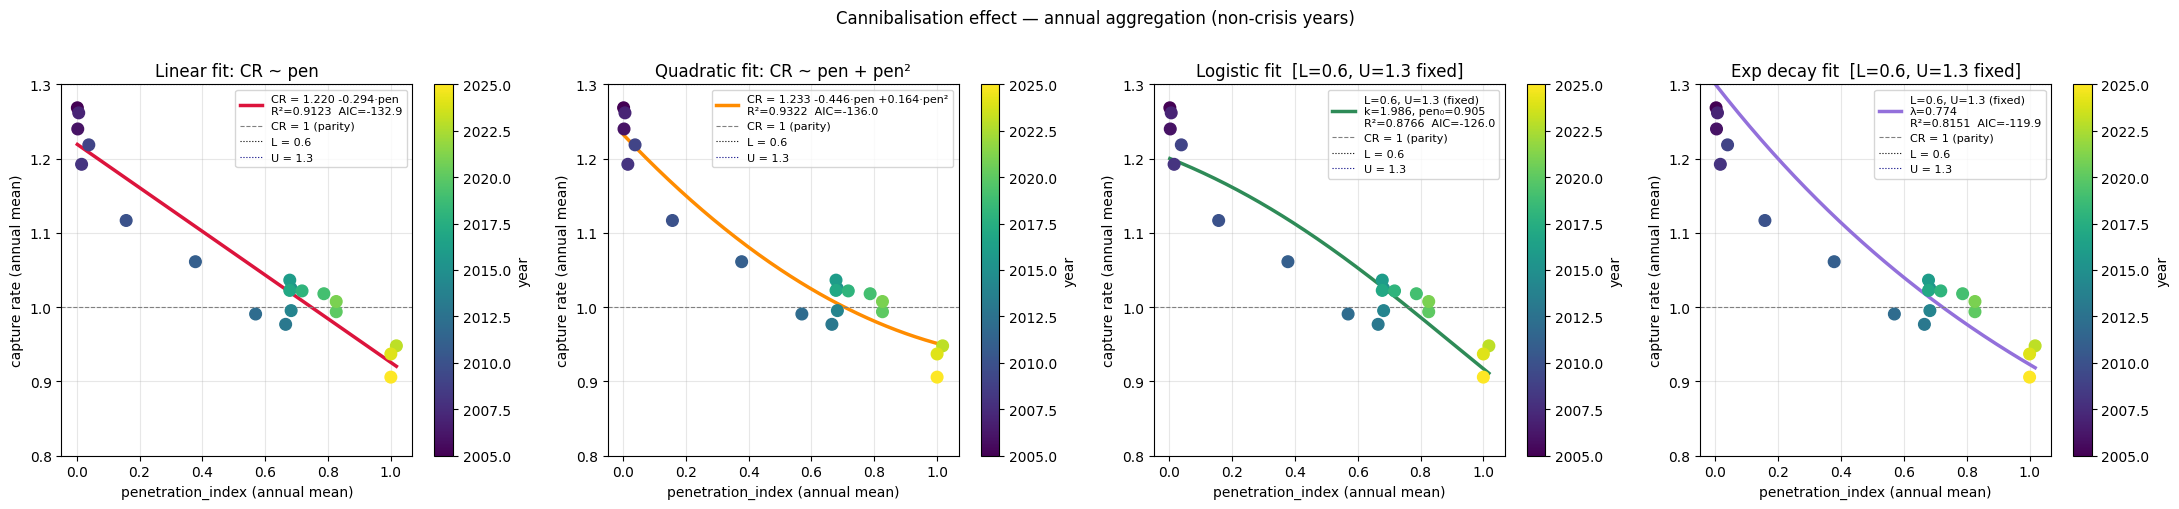

In [94]:
# ── Annual mean: capture rate vs penetration_index ────────────────────────────
# Linear, Quadratic, Logistic, and Exponential fits (L_FIXED, U_FIXED fixed)

from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# ── Constants ─────────────────────────────────────────────────────────────────
L_FIXED = 0.6
U_FIXED = 1.3

# ── Aggregation ───────────────────────────────────────────────────────────────
annual = (
    df_daily[df_daily["crisis"] == 0]
    .groupby("year")
    .agg(
        cr_mean  = ("capture_rate",      "mean"),
        pen_mean = ("penetration_index", "mean"),
    )
    .dropna()
    .query("cr_mean > 0 and cr_mean < 3")
    .reset_index()
)

pen      = annual["pen_mean"].values
cr       = annual["cr_mean"].values
years    = annual["year"].values
pen_line = np.linspace(pen.min(), pen.max(), 200)
n_obs    = len(pen)

if cr.max() > U_FIXED:
    print(f"  WARNING: cr.max()={cr.max():.4f} > U_FIXED={U_FIXED} — raise U_FIXED.")
if cr.min() < L_FIXED:
    print(f"  WARNING: cr.min()={cr.min():.4f} < L_FIXED={L_FIXED} — lower L_FIXED.")

# ── helper: AIC / BIC ─────────────────────────────────────────────────────────
def aic_bic(residuals, k):
    n   = len(residuals)
    rss = np.sum(residuals**2)
    ll  = -n / 2 * np.log(rss / n)   # log-likelihood (Gaussian)
    return 2 * k - 2 * ll, np.log(n) * k - 2 * ll

# ── Linear OLS: CR = a + b·pen ───────────────────────────────────────────────
X_lin = np.column_stack([pen, np.ones(n_obs)])
b_lin, _, _, _ = np.linalg.lstsq(X_lin, cr, rcond=None)
cr_lin     = b_lin[0] * pen_line + b_lin[1]
res_lin    = cr - X_lin @ b_lin
r2_lin     = 1 - np.sum(res_lin**2) / np.sum((cr - cr.mean())**2)
aic_lin, bic_lin = aic_bic(res_lin, k=2)

# ── Quadratic OLS: CR = a + b·pen + c·pen² ───────────────────────────────────
X_quad = np.column_stack([pen**2, pen, np.ones(n_obs)])
b_quad, _, _, _ = np.linalg.lstsq(X_quad, cr, rcond=None)
cr_quad    = b_quad[0] * pen_line**2 + b_quad[1] * pen_line + b_quad[2]
res_quad   = cr - X_quad @ b_quad
r2_quad    = 1 - np.sum(res_quad**2) / np.sum((cr - cr.mean())**2)
aic_quad, bic_quad = aic_bic(res_quad, k=3)

# ── Logistic: CR = L + (U-L) / (1 + exp(k·(pen - pen0))) ────────────────────
def logistic(x, k, pen0):
    return L_FIXED + (U_FIXED - L_FIXED) / (1 + np.exp(k * (x - pen0)))

try:
    popt, _ = curve_fit(logistic, pen, cr,
                        p0=[5.0, pen.mean()],
                        bounds=([0.0, pen.min()], [50.0, pen.max()]),
                        maxfev=10000)
    cr_logistic  = logistic(pen_line, *popt)
    res_log      = cr - logistic(pen, *popt)
    r2_log       = 1 - np.sum(res_log**2) / np.sum((cr - cr.mean())**2)
    aic_log, bic_log = aic_bic(res_log, k=2)
    log_label    = (f"L={L_FIXED}, U={U_FIXED} (fixed)\n"
                    f"k={popt[0]:.3f}, pen₀={popt[1]:.3f}\nR²={r2_log:.4f}")
    log_ok = True
except (RuntimeError, ValueError) as e:
    log_ok = False
    print(f"  WARNING: logistic fit failed — {e}")

# ── Exponential decay: CR = L + (U-L)·exp(-λ·pen) ───────────────────────────
def exp_decay(x, lam):
    return L_FIXED + (U_FIXED - L_FIXED) * np.exp(-lam * x)

try:
    popt_exp, _ = curve_fit(exp_decay, pen, cr,
                            p0=[1.0],
                            bounds=([0.0], [50.0]),
                            maxfev=10000)
    cr_exp    = exp_decay(pen_line, *popt_exp)
    res_exp   = cr - exp_decay(pen, *popt_exp)
    r2_exp    = 1 - np.sum(res_exp**2) / np.sum((cr - cr.mean())**2)
    aic_exp, bic_exp = aic_bic(res_exp, k=1)
    exp_label = (f"L={L_FIXED}, U={U_FIXED} (fixed)\n"
                 f"λ={popt_exp[0]:.3f}\nR²={r2_exp:.4f}")
    exp_ok = True
except (RuntimeError, ValueError) as e:
    exp_ok = False
    print(f"  WARNING: exponential fit failed — {e}")

# ── Summary table ─────────────────────────────────────────────────────────────
print("── Regression summary (n={}) ─────────────────────────────────────────".format(n_obs))
print(f"  {'Model':<14} {'Params':<40} {'k':>2}  {'R²':>7}  {'AIC':>8}  {'BIC':>8}")
print(f"  {'-'*85}")
print(f"  {'Linear':<14} "
      f"CR = {b_lin[1]:.4f} {b_lin[0]:+.4f}·pen{'':<18} "
      f"{'2':>2}  {r2_lin:>7.4f}  {aic_lin:>8.2f}  {bic_lin:>8.2f}")
print(f"  {'Quadratic':<14} "
      f"CR = {b_quad[2]:.4f} {b_quad[1]:+.4f}·pen {b_quad[0]:+.4f}·pen²{'':<5} "
      f"{'3':>2}  {r2_quad:>7.4f}  {aic_quad:>8.2f}  {bic_quad:>8.2f}")
if log_ok:
    print(f"  {'Logistic':<14} "
          f"L={L_FIXED}, U={U_FIXED}, k={popt[0]:.4f}, pen₀={popt[1]:.4f}{'':<8} "
          f"{'2':>2}  {r2_log:>7.4f}  {aic_log:>8.2f}  {bic_log:>8.2f}")
if exp_ok:
    print(f"  {'Exp decay':<14} "
          f"L={L_FIXED}, U={U_FIXED}, λ={popt_exp[0]:.4f}{'':<22} "
          f"{'1':>2}  {r2_exp:>7.4f}  {aic_exp:>8.2f}  {bic_exp:>8.2f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

fits = [
    (axes[0], cr_lin,                            f"CR = {b_lin[1]:.3f} {b_lin[0]:+.3f}·pen\nR²={r2_lin:.4f}  AIC={aic_lin:.1f}",   "crimson"),
    (axes[1], cr_quad,                           f"CR = {b_quad[2]:.3f} {b_quad[1]:+.3f}·pen {b_quad[0]:+.3f}·pen²\nR²={r2_quad:.4f}  AIC={aic_quad:.1f}", "darkorange"),
    (axes[2], cr_logistic if log_ok else cr_lin, log_label + f"  AIC={aic_log:.1f}" if log_ok else "fit failed", "seagreen"),
    (axes[3], cr_exp      if exp_ok else cr_lin, exp_label + f"  AIC={aic_exp:.1f}" if exp_ok else "fit failed", "mediumpurple"),
]
titles = [
    "Linear fit: CR ~ pen",
    "Quadratic fit: CR ~ pen + pen²",
    f"Logistic fit  [L={L_FIXED}, U={U_FIXED} fixed]",
    f"Exp decay fit  [L={L_FIXED}, U={U_FIXED} fixed]",
]

for (ax, cr_fit, label, color), title in zip(fits, titles):
    sc = ax.scatter(pen, cr, c=years, cmap="viridis", s=70, zorder=3)
    ax.plot(pen_line, cr_fit, color=color, lw=2.5, label=label)
    ax.axhline(1.0,     color="grey",  lw=0.8, ls="--", label="CR = 1 (parity)")
    ax.axhline(L_FIXED, color="black", lw=0.8, ls=":",  label=f"L = {L_FIXED}")
    ax.axhline(U_FIXED, color="navy",  lw=0.8, ls=":",  label=f"U = {U_FIXED}")
    plt.colorbar(sc, ax=ax, label="year")
    ax.set_xlabel("penetration_index (annual mean)")
    ax.set_ylabel("capture rate (annual mean)")
    ax.set_ylim(0.8, 1.3)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Cannibalisation effect — annual aggregation (non-crisis years)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


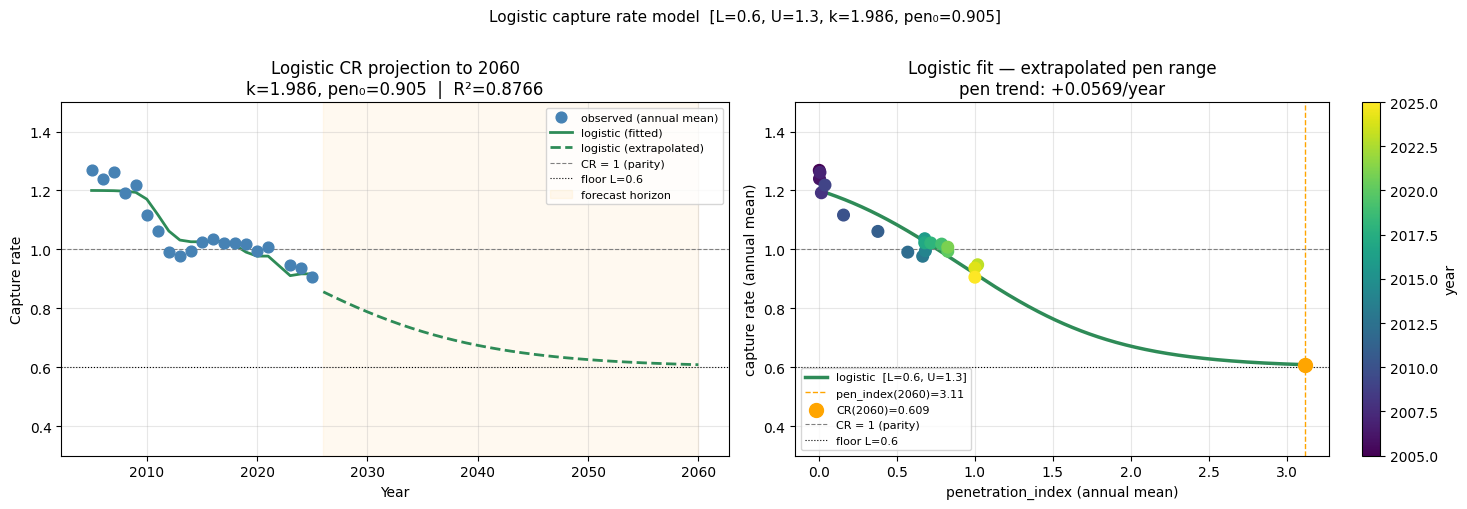

── Logistic projection summary ──────────────────────────────────────
  pen trend: +0.05685/year  (intercept=-113.9993)
  2030: pen_index=1.409  →  CR=0.7879
  2040: pen_index=1.978  →  CR=0.6742
  2050: pen_index=2.546  →  CR=0.6259
  2060: pen_index=3.115  →  CR=0.6086


In [95]:
# ── Logistic projection to 2060 ──────────────────────────────────────────────
# Two views: (1) CR vs Year  |  (2) CR vs pen_index with extrapolation
# Requires: annual, pen, cr, years, popt, logistic, L_FIXED, U_FIXED, r2_log

# ── derive year/pen arrays from annual (defined in previous cell) ─────────────
year_vals = annual["year"].values.astype(float)
pen_vals  = annual["pen_mean"].values

# project penetration_index linearly to 2060
b_trend, _, _, _ = np.linalg.lstsq(
    np.column_stack([year_vals, np.ones(len(year_vals))]), pen_vals, rcond=None
)
slope_trend, intercept_trend = b_trend

years_hist = year_vals
years_fc   = np.arange(year_vals.max() + 1, 2061, dtype=float)

pen_hist = pen_vals
pen_fc   = np.clip(slope_trend * years_fc + intercept_trend, 0, 5.0)

cr_hist_fit = logistic(pen_hist, *popt)
cr_fc_fit   = logistic(pen_fc,   *popt)

# extended pen axis for right panel
pen_ext = np.linspace(pen.min(), pen_fc.max(), 400)
cr_ext  = logistic(pen_ext, *popt)

# 2060 endpoint
pen_2060 = np.clip(slope_trend * 2060 + intercept_trend, 0, 5.0)
cr_2060  = logistic(pen_2060, *popt)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# left: CR vs Year
axes[0].scatter(years_hist, cr, s=60, color="steelblue", zorder=4,
                label="observed (annual mean)")
axes[0].plot(years_hist, cr_hist_fit, color="seagreen", lw=2,
             label="logistic (fitted)")
axes[0].plot(years_fc, cr_fc_fit, color="seagreen", lw=2, ls="--",
             label="logistic (extrapolated)")
axes[0].axhline(1.0,     color="grey",  lw=0.8, ls="--", label="CR = 1 (parity)")
axes[0].axhline(L_FIXED, color="black", lw=0.8, ls=":",  label=f"floor L={L_FIXED}")
axes[0].axvspan(years_fc.min(), 2060, alpha=0.06, color="orange",
                label="forecast horizon")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Capture rate")
axes[0].set_ylim(0.3, 1.5)
axes[0].set_title("Logistic CR projection to 2060\n"
                  f"k={popt[0]:.3f}, pen₀={popt[1]:.3f}  |  R²={r2_log:.4f}")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# right: pen_index vs CR
sc = axes[1].scatter(pen_hist, cr, c=years_hist, cmap="viridis", s=70, zorder=4)
axes[1].plot(pen_ext, cr_ext, color="seagreen", lw=2.5,
             label=f"logistic  [L={L_FIXED}, U={U_FIXED}]")
axes[1].axvline(pen_2060, color="orange", lw=1, ls="--",
                label=f"pen_index(2060)={pen_2060:.2f}")
axes[1].scatter([pen_2060], [cr_2060], s=100, color="orange", zorder=5,
                label=f"CR(2060)={cr_2060:.3f}")
axes[1].axhline(1.0,     color="grey",  lw=0.8, ls="--", label="CR = 1 (parity)")
axes[1].axhline(L_FIXED, color="black", lw=0.8, ls=":",  label=f"floor L={L_FIXED}")
plt.colorbar(sc, ax=axes[1], label="year")
axes[1].set_xlabel("penetration_index (annual mean)")
axes[1].set_ylabel("capture rate (annual mean)")
axes[1].set_ylim(0.3, 1.5)
axes[1].set_title("Logistic fit — extrapolated pen range\n"
                  f"pen trend: {slope_trend:+.4f}/year")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle(f"Logistic capture rate model  [L={L_FIXED}, U={U_FIXED}, "
             f"k={popt[0]:.3f}, pen₀={popt[1]:.3f}]",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print(f"── Logistic projection summary ──────────────────────────────────────")
print(f"  pen trend: {slope_trend:+.5f}/year  (intercept={intercept_trend:.4f})")
for yr in [2030, 2040, 2050, 2060]:
    pen_yr = np.clip(slope_trend * yr + intercept_trend, 0, 5.0)
    cr_yr  = logistic(pen_yr, *popt)
    print(f"  {yr}: pen_index={pen_yr:.3f}  →  CR={cr_yr:.4f}")



── Step 6: Capture rate by period ───────────────────────────────
  Period                         mean CR     std     p10     p50     p90      n
  2005–2010 (pre-solar)           1.2162  0.1453  1.0437  1.2027  1.4166   2191
  2011–2016 (solar boom)          1.0142  0.1157  0.8957  1.0342  1.1216   2192
  2017–2021 (stable)              1.0130  0.0942  0.9166  1.0221  1.1073   1734
  2023–2025 (post-crisis)         0.9266  0.1242  0.7919  0.9505  1.0362    915


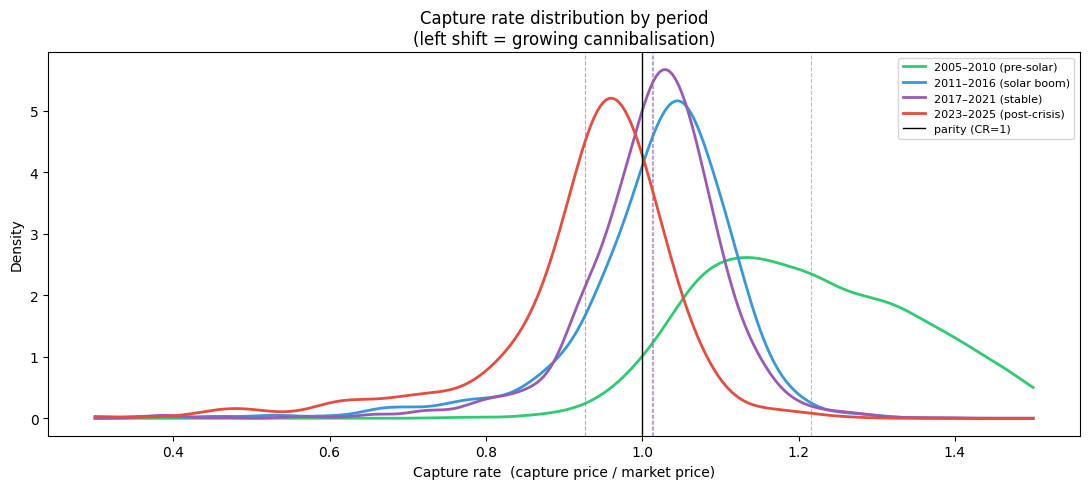

In [ ]:
#  Capture rate by penetration period
# ─────────────────────────────────────────────────────────────────────────────
 
periods = {
    "2005–2010 (pre-solar)":   (2005, 2010),
    "2011–2016 (solar boom)":  (2011, 2016),
    "2017–2021 (stable)":      (2017, 2021),
    "2023–2025 (post-crisis)": (2023, 2025),
}
 
print(f"\n── Step 6: Capture rate by period ───────────────────────────────")
print(f"  {'Period':<28}  {'mean CR':>8}  {'std':>6}  "
      f"{'p10':>6}  {'p50':>6}  {'p90':>6}  {'n':>5}")
 
fig, ax = plt.subplots(figsize=(11, 5))
colors_p = ["#2ECC71","#3498DB","#9B59B6","#E74C3C"]
 
for (label, (yr_lo, yr_hi)), col in zip(periods.items(), colors_p):
    m   = (
        (df_daily["year"] >= yr_lo) &
        (df_daily["year"] <= yr_hi) &
        (df_daily["crisis"] == 0) &
        df_daily["capture_rate"].notna() &
        (df_daily["capture_rate"] > 0) &
        (df_daily["capture_rate"] < 3)
    )
    sub = df_daily.loc[m, "capture_rate"]
    print(f"  {label:<28}  {sub.mean():>8.4f}  {sub.std():>6.4f}  "
          f"{sub.quantile(0.1):>6.4f}  {sub.quantile(0.5):>6.4f}  "
          f"{sub.quantile(0.9):>6.4f}  {len(sub):>5}")
 
    kde_x = np.linspace(0.3, 1.5, 300)
    kde   = stats.gaussian_kde(sub)
    ax.plot(kde_x, kde(kde_x), lw=2, color=col, label=label)
    ax.axvline(sub.mean(), color=col, lw=0.8, ls="--", alpha=0.6)
 
ax.axvline(1.0, color="black", lw=1, ls="-", label="parity (CR=1)")
ax.set_xlabel("Capture rate  (capture price / market price)")
ax.set_ylabel("Density")
ax.set_title("Capture rate distribution by period\n"
             "(left shift = growing cannibalisation)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


── Step 5: Hourly price profiles by KT quintile ─────────────────
kt_quintile  Q1 very cloudy  Q2 cloudy  Q3 medium  Q4 clear  Q5 very clear
hour                                                                      
0                     58.35      57.56      58.52     59.06          60.89
1                     52.64      51.98      53.31     53.95          55.97
2                     49.02      48.55      50.05     50.43          52.63
3                     46.68      46.42      47.88     48.26          50.46
4                     46.48      46.41      47.77     47.92          50.23
5                     50.82      50.21      50.88     50.95          53.44
6                     60.97      59.46      59.41     59.52          61.71
7                     71.04      68.99      68.20     67.81          69.69
8                     80.61      77.57      76.35     75.96          77.10
9                     85.46      82.09      79.32     79.88          80.55
10                    83.82      

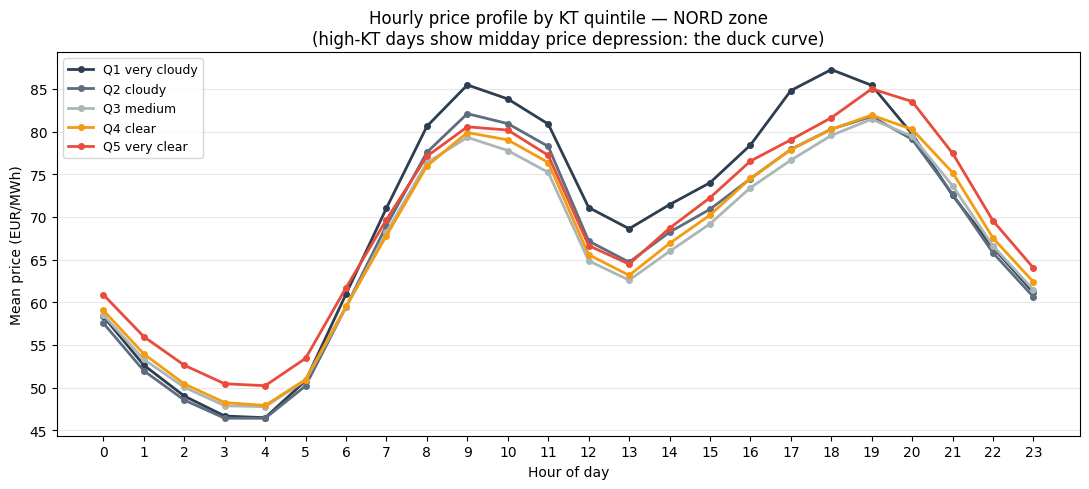

In [ ]:
# Hourly price profile on high-KT vs low-KT days
# ─────────────────────────────────────────────────────────────────────────────
 
# classify days into KT quintiles
kt_quintiles = pd.qcut(
    df_daily["KT_daily"].dropna(), q=5,
    labels=["Q1 very cloudy","Q2 cloudy","Q3 medium",
            "Q4 clear","Q5 very clear"]
)
df_daily["kt_quintile"] = kt_quintiles
 
# map back to hourly
df_hourly_kt = df_hourly.merge(
    df_daily[["date","kt_quintile"]], on="date", how="left"
)
 
# hourly mean price by hour and KT quintile
hourly_profile = (
    df_hourly_kt[df_hourly_kt["crisis"]==0]
    .groupby(["hour","kt_quintile"])["price_NORD_EURMWh"]
    .mean()
    .reset_index()
)
 
print(f"\n── Step 5: Hourly price profiles by KT quintile ─────────────────")
pivot = hourly_profile.pivot(
    index="hour", columns="kt_quintile", values="price_NORD_EURMWh"
)
print(pivot.round(2).to_string())
 
colors_kt = ["#2C3E50","#5D6D7E","#AAB7B8","#F39C12","#E74C3C"]
fig, ax   = plt.subplots(figsize=(11, 5))
for (quint, col) in zip(["Q1 very cloudy","Q2 cloudy","Q3 medium",
                           "Q4 clear","Q5 very clear"], colors_kt):
    sub = pivot[quint].dropna()
    ax.plot(sub.index, sub.values, lw=2, color=col, label=quint, marker="o",
            ms=4)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean price (EUR/MWh)")
ax.set_title("Hourly price profile by KT quintile — NORD zone\n"
             "(high-KT days show midday price depression: the duck curve)")
ax.legend(fontsize=9, loc="upper left")
ax.set_xticks(range(0, 24))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Patterns Modelling

In [98]:
CRISIS_START = "2021-10-01"
CRISIS_END   = "2023-06-30"
N_HARMONICS  = 4
DAY_NAMES    = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
REFERENCE_YEAR = 11.5   # reference solar share % for penetration_index


# logistic asymptotes — fixed by economic reasoning
L_FIXED = 0.6   # lower asymptote: capture rate floor at very high penetration


In [99]:
# LOGISTIC FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
 
def logistic(pen, k, pen0):
    """
    Two-parameter logistic with fixed asymptotes L_FIXED and U_FIXED.
    Direct predictor of CR level — output in same scale as capture rate.
    Bounded: CR → L_FIXED as pen → ∞, CR → U_FIXED as pen → 0.
    """
    return L_FIXED + (U_FIXED - L_FIXED) / (1 + np.exp(k * (pen - pen0)))

In [100]:
# ── penetration index ─────────────────────────────────────────────────────────
if "penetration_index" not in df_daily.columns:
    solar_share_pct = {
        2005:0.02, 2006:0.03, 2007:0.05, 2008:0.10, 2009:0.26,
        2010:0.63, 2011:3.00, 2012:5.70, 2013:7.40, 2014:7.90,
        2015:7.80, 2016:7.90, 2017:7.70, 2018:7.90, 2019:8.60,
        2020:9.50, 2021:9.50, 2022:9.50, 2023:12.30, 2024:11.50,
    }
    lookup_years = np.array(sorted(solar_share_pct) + [2025], dtype=float)
    lookup_vals  = np.array(
        [solar_share_pct[yr]/REFERENCE_YEAR
         for yr in sorted(solar_share_pct)]
        + [solar_share_pct[2024]/REFERENCE_YEAR], dtype=float
    )
    doy_d  = pd.to_datetime(df_daily["date"]).dt.dayofyear
    dec_yr = df_daily["year"].astype(float) + (doy_d - 1) / 365.0
    df_daily["penetration_index"] = np.interp(
        dec_yr, lookup_years, lookup_vals
    )

In [101]:
# ── working sample ────────────────────────────────────────────────────────────
mask = (
    df_daily["capture_rate"].notna() &
    (df_daily["capture_rate"] > 0) &
    (df_daily["capture_rate"] < 3) &
    df_daily["penetration_index"].notna()
)
s_df = df_daily[mask].copy().reset_index(drop=True)
s_df["date"]       = pd.to_datetime(s_df["date"])
s_df["weekday"]    = s_df["date"].dt.weekday
s_df["is_weekend"] = (s_df["weekday"] >= 5).astype(int)
s_df["month"]      = s_df["date"].dt.month
 
print("── Sample ───────────────────────────────────────────────────────")
print(f"  Total days  : {len(s_df)}")
print(f"  Crisis days : {s_df['crisis'].sum()}")
print(f"  Normal days : {(s_df['crisis']==0).sum()}")
print(f"  Date range  : {s_df['date'].min().date()} → "
      f"{s_df['date'].max().date()}")
print(f"  CR mean     : {s_df['capture_rate'].mean():.4f}")
print(f"  CR std      : {s_df['capture_rate'].std():.4f}")
print(f"  pen_index   : [{s_df['penetration_index'].min():.4f}, "
      f"{s_df['penetration_index'].max():.4f}]")

── Sample ───────────────────────────────────────────────────────
  Total days  : 7670
  Crisis days : 638
  Normal days : 7032
  Date range  : 2005-01-01 → 2025-12-31
  CR mean     : 1.0584
  CR std      : 0.1591
  pen_index   : [0.0017, 1.0696]


In [102]:
# STEP 1A — Determine U_FIXED from near-zero penetration years
# ─────────────────────────────────────────────────────────────────────────────
# U_FIXED = empirical CR at near-zero penetration (pre-solar era).
# Use days where pen_index < 0.05 and no crisis — this captures the
# baseline capture rate before solar deployment had any market effect.
 
pre_solar_mask = (
    (s_df["penetration_index"] < 0.05) &
    (s_df["crisis"] == 0) &
    s_df["capture_rate"].notna()
)
U_FIXED = float(s_df.loc[pre_solar_mask, "capture_rate"].mean())
 
print(f"\n── Step 1A: Determine U_FIXED ───────────────────────────────────")
print(f"  Pre-solar days (pen<0.05): {pre_solar_mask.sum()}")
print(f"  Mean CR in pre-solar era : {U_FIXED:.5f}")
print(f"  U_FIXED set to           : {U_FIXED:.5f}")
print(f"  L_FIXED (floor)          : {L_FIXED:.2f}")
print(f"  Logistic range           : [{L_FIXED:.2f}, {U_FIXED:.4f}]")


── Step 1A: Determine U_FIXED ───────────────────────────────────
  Pre-solar days (pen<0.05): 1772
  Mean CR in pre-solar era : 1.23995
  U_FIXED set to           : 1.23995
  L_FIXED (floor)          : 0.60
  Logistic range           : [0.60, 1.2399]


In [103]:
# STEP 1B — Fit logistic on annual means (estimate k and pen₀)
# ─────────────────────────────────────────────────────────────────────────────
 
ann_agg = (
    s_df[s_df["crisis"]==0]
    .groupby("year")
    .agg(
        cr_mean  = ("capture_rate",      "mean"),
        pen_mean = ("penetration_index", "mean"),
    )
    .reset_index()
)
 
popt, pcov = curve_fit(
    logistic,
    ann_agg["pen_mean"].values,
    ann_agg["cr_mean"].values,
    p0     = [5.0, 0.50],
    bounds = ([0.5, 0.01], [20.0, 1.50]),
    maxfev = 10000
)
k_fit, pen0_fit = popt
perr = np.sqrt(np.diag(pcov))
 
# R² on annual means — now meaningful since logistic and CR are same scale
cr_pred_ann = logistic(ann_agg["pen_mean"].values, k_fit, pen0_fit)
ss_res_ann  = np.sum((ann_agg["cr_mean"].values - cr_pred_ann)**2)
ss_tot_ann  = np.sum((ann_agg["cr_mean"].values
                      - ann_agg["cr_mean"].values.mean())**2)
r2_logistic = 1 - ss_res_ann / ss_tot_ann
 
print(f"\n── Step 1B: Logistic fit on annual means ────────────────────────")
print(f"  U_FIXED = {U_FIXED:.5f}  (fixed — pre-solar CR level)")
print(f"  L_FIXED = {L_FIXED:.2f}     (fixed — CR floor)")
print(f"  k       = {k_fit:.4f}  se={perr[0]:.4f}  (steepness)")
print(f"  pen₀    = {pen0_fit:.4f}  se={perr[1]:.4f}  (inflection point)")
print(f"  R²      = {r2_logistic:.4f}  (annual means)")
 
print(f"\n  Residuals from logistic fit on annual means:")
print(f"  {'Year':>4}  {'obs':>8}  {'logistic':>10}  {'resid':>8}")
for yr, obs, pred in zip(ann_agg["year"],
                          ann_agg["cr_mean"],
                          cr_pred_ann):
    print(f"  {int(yr):>4}  {obs:>8.5f}  {pred:>10.5f}  "
          f"{obs-pred:>+8.5f}")
 
print(f"\n  Forward projections:")
print(f"  {'pen':>5}  {'~year':>6}  {'CR':>8}")
for pen_val, yr_lbl in [(0.5,"~2012"), (1.0,"2024"), (1.5,"2027"),
                         (2.0,"2030"), (3.0,"2040"), (5.0,"2050+")]:
    cr_proj = logistic(pen_val, k_fit, pen0_fit)
    print(f"  {pen_val:>5.1f}  {yr_lbl:>6}  {cr_proj:>8.4f}")


── Step 1B: Logistic fit on annual means ────────────────────────
  U_FIXED = 1.23995  (fixed — pre-solar CR level)
  L_FIXED = 0.60     (fixed — CR floor)
  k       = 2.4133  se=0.3569  (steepness)
  pen₀    = 0.9818  se=0.0493  (inflection point)
  R²      = 0.8447  (annual means)

  Residuals from logistic fit on annual means:
  Year       obs    logistic     resid
  2005   1.26842     1.18494  +0.08347
  2006   1.23988     1.18478  +0.05510
  2007   1.26157     1.18441  +0.07716
  2008   1.19230     1.18328  +0.00901
  2009   1.21849     1.18035  +0.03814
  2010   1.11662     1.16293  -0.04631
  2011   1.06112     1.11907  -0.05795
  2012   0.99066     1.06719  -0.07653
  2013   0.97676     1.03660  -0.05984
  2014   0.99525     1.03071  -0.03546
  2015   1.02494     1.03072  -0.00578
  2016   1.03629     1.03219  +0.00410
  2017   1.02245     1.03220  -0.00975
  2018   1.02180     1.01876  +0.00304
  2019   1.01799     0.99388  +0.02411
  2020   0.99374     0.97939  +0.01434
  20

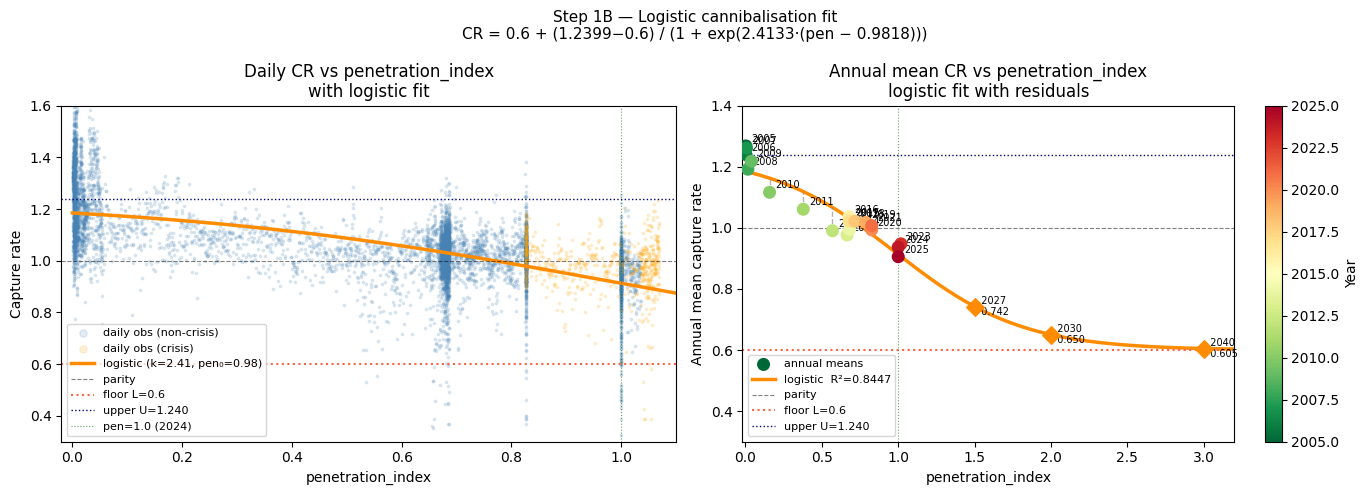

In [104]:
# ── Step 1B plot: CR vs penetration_index with logistic fit ──────────────────

pen_line     = np.linspace(0, 5.0, 500)
cr_log_curve = logistic(pen_line, k_fit, pen0_fit)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── left panel: daily scatter + logistic ─────────────────────────────────────
ax = axes[0]
ax.scatter(
    s_df.loc[s_df["crisis"]==0, "penetration_index"],
    s_df.loc[s_df["crisis"]==0, "capture_rate"],
    s=3, alpha=0.15, color="steelblue", label="daily obs (non-crisis)"
)
ax.scatter(
    s_df.loc[s_df["crisis"]==1, "penetration_index"],
    s_df.loc[s_df["crisis"]==1, "capture_rate"],
    s=3, alpha=0.15, color="orange", label="daily obs (crisis)"
)
ax.plot(pen_line, cr_log_curve, color="darkorange", lw=2.5,
        label=f"logistic (k={k_fit:.2f}, pen₀={pen0_fit:.2f})")
ax.axhline(1.0,     color="black",  lw=0.8, ls="--", alpha=0.5,
           label="parity")
ax.axhline(L_FIXED, color="tomato", lw=1.5, ls=":",
           label=f"floor L={L_FIXED}")
ax.axhline(U_FIXED, color="navy",   lw=1.0, ls=":",
           label=f"upper U={U_FIXED:.3f}")
ax.axvline(1.0, color="darkgreen", lw=0.8, ls=":", alpha=0.6,
           label="pen=1.0 (2024)")
ax.set_xlabel("penetration_index")
ax.set_ylabel("Capture rate")
ax.legend(fontsize=8, markerscale=3)
ax.set_title("Daily CR vs penetration_index\n"
             "with logistic fit")
ax.set_xlim(-0.02, 1.1)
ax.set_ylim(0.3, 1.6)

# ── right panel: annual means + logistic + residuals ─────────────────────────
ax = axes[1]

sc = ax.scatter(
    ann_agg["pen_mean"],
    ann_agg["cr_mean"],
    c=ann_agg["year"], cmap="RdYlGn_r",
    s=70, zorder=5, label="annual means"
)
plt.colorbar(sc, ax=ax, label="Year")

for _, row in ann_agg.iterrows():
    ax.annotate(
        str(int(row["year"])),
        (row["pen_mean"], row["cr_mean"]),
        fontsize=7, xytext=(4, 3),
        textcoords="offset points"
    )

ax.plot(pen_line, cr_log_curve, color="darkorange", lw=2.5,
        label=f"logistic  R²={r2_logistic:.4f}")

# draw vertical residual lines from each annual point to the logistic curve
for _, row in ann_agg.iterrows():
    cr_pred_pt = logistic(row["pen_mean"], k_fit, pen0_fit)
    ax.plot(
        [row["pen_mean"], row["pen_mean"]],
        [row["cr_mean"],  cr_pred_pt],
        color="grey", lw=1.0, ls="--", alpha=0.6
    )

ax.axhline(1.0,     color="black",  lw=0.8, ls="--", alpha=0.5,
           label="parity")
ax.axhline(L_FIXED, color="tomato", lw=1.5, ls=":",
           label=f"floor L={L_FIXED}")
ax.axhline(U_FIXED, color="navy",   lw=1.0, ls=":",
           label=f"upper U={U_FIXED:.3f}")
ax.axvline(1.0, color="darkgreen", lw=0.8, ls=":", alpha=0.6)

# mark future penetration points
for pen_v, yr_l in [(1.5,"2027"), (2.0,"2030"), (3.0,"2040")]:
    cr_v = logistic(pen_v, k_fit, pen0_fit)
    ax.scatter(pen_v, cr_v, s=80, color="darkorange",
               zorder=6, marker="D")
    ax.annotate(f"  {yr_l}\n  {cr_v:.3f}",
                (pen_v, cr_v), fontsize=7, va="center")

ax.set_xlabel("penetration_index")
ax.set_ylabel("Annual mean capture rate")
ax.legend(fontsize=8)
ax.set_title("Annual mean CR vs penetration_index\n"
             "logistic fit with residuals")
ax.set_xlim(-0.02, 3.2)
ax.set_ylim(0.3, 1.4)

plt.suptitle(
    f"Step 1B — Logistic cannibalisation fit\n"
    f"CR = {L_FIXED} + ({U_FIXED:.4f}−{L_FIXED}) / "
    f"(1 + exp({k_fit:.4f}·(pen − {pen0_fit:.4f})))",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [105]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1C — Joint OLS: logistic term + Fourier + crisis + Sat + Sun dummies
# ─────────────────────────────────────────────────────────────────────────────
# The logistic term enters as a regressor — β_log scales the penetration
# contribution. Fourier terms include an intercept to absorb the baseline.
# Saturday and Sunday have separate dummies — Mon–Fri is the reference.

pen_index     = s_df["penetration_index"].values
logistic_term = logistic(pen_index, k_fit, pen0_fit)
s_df["logistic_term"] = logistic_term

# Fourier terms WITH intercept
doy = s_df["date"].dt.dayofyear.values
t   = (doy - 1) / 365.0

col_names = ["intercept"]
X_fourier = [np.ones(len(s_df))]
for k in range(1, N_HARMONICS + 1):
    X_fourier.extend([np.cos(2*np.pi*k*t), np.sin(2*np.pi*k*t)])
    col_names.extend([f"cos({k}·2πt)", f"sin({k}·2πt)"])
X_fourier = np.column_stack(X_fourier)

# crisis, Saturday and Sunday dummies
crisis_flag   = (
    (s_df["date"] >= CRISIS_START) &
    (s_df["date"] <= CRISIS_END)
).astype(float).values
saturday_flag = (s_df["weekday"] == 5).astype(float).values
sunday_flag   = (s_df["weekday"] == 6).astype(float).values

# full design matrix
X_fit = np.column_stack([
    X_fourier,
    logistic_term,
    crisis_flag,
    saturday_flag,
    sunday_flag,
])
col_names_fit = col_names + [
    "logistic_pen(k,pen₀)",
    "crisis_dummy",
    "saturday_dummy",
    "sunday_dummy",
]

y        = s_df["capture_rate"].values
n_fit    = len(s_df)
n_params = X_fit.shape[1]

# OLS on raw CR — joint estimation
beta_f, _, _, _ = np.linalg.lstsq(X_fit, y, rcond=None)

n_fourier     = X_fourier.shape[1]
beta_fourier  = beta_f[:n_fourier]
beta_log      = beta_f[n_fourier]
beta_crisis   = beta_f[n_fourier + 1]
beta_saturday = beta_f[n_fourier + 2]
beta_sunday   = beta_f[n_fourier + 3]

# standard errors
y_hat     = X_fit @ beta_f
resid_all = y - y_hat
s2        = np.sum(resid_all**2) / (n_fit - n_params)
XtX_inv   = np.linalg.inv(X_fit.T @ X_fit)
se_beta   = np.sqrt(np.diag(s2 * XtX_inv))
t_stats   = beta_f / se_beta
p_vals    = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n_fit - n_params))

ss_res = np.sum(resid_all**2)
ss_tot = np.sum((y - y.mean())**2)
r2     = 1 - ss_res / ss_tot

print(f"\n── Step 1C: Joint OLS (full sample n={n_fit}) ───────────────────")
print(f"  N parameters : {n_params}")
print(f"  R²           : {r2:.4f}")
print(f"\n  {'Variable':<26}  {'coef':>10}  {'se':>8}  {'t':>7}  sig")
print(f"  {'-'*26}  {'-'*10}  {'-'*8}  {'-'*7}  ---")
for name, b, se, t_s, p in zip(col_names_fit, beta_f,
                                 se_beta, t_stats, p_vals):
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
    print(f"  {name:<26}  {b:>+10.6f}  {se:>8.6f}  {t_s:>7.3f}  {sig}")

print(f"\n  Key coefficients:")
print(f"    β_log      = {beta_log:+.5f}  (scales logistic penetration term)")
print(f"    β_crisis   = {beta_crisis:+.5f}")
print(f"    β_saturday = {beta_saturday:+.5f}")
print(f"    β_sunday   = {beta_sunday:+.5f}")

print(f"\n  μ_CR forward projections (intercept + logistic, no seasonal):")
for pen_val, yr_lbl in [(1.0,"2024"), (1.5,"2027"),
                         (2.0,"2030"), (3.0,"2040"), (5.0,"2050+")]:
    log_t = logistic(pen_val, k_fit, pen0_fit)
    mu_cr = beta_f[0] + beta_log * log_t
    print(f"    pen={pen_val:.1f} (~{yr_lbl}): μ_CR ≈ {mu_cr:.4f}")


── Step 1C: Joint OLS (full sample n=7670) ───────────────────
  N parameters : 13
  R²           : 0.5713

  Variable                          coef        se        t  sig
  --------------------------  ----------  --------  -------  ---
  intercept                    -0.057649  0.014165   -4.070  ***
  cos(1·2πt)                   +0.004207  0.001685    2.498  *
  sin(1·2πt)                   -0.014333  0.001687   -8.495  ***
  cos(2·2πt)                   +0.014332  0.001683    8.516  ***
  sin(2·2πt)                   +0.000248  0.001685    0.147  n.s.
  cos(3·2πt)                   -0.009899  0.001683   -5.881  ***
  sin(3·2πt)                   +0.012320  0.001684    7.314  ***
  cos(4·2πt)                   +0.006892  0.001683    4.095  ***
  sin(4·2πt)                   +0.000388  0.001684    0.230  n.s.
  logistic_pen(k,pen₀)         +1.094238  0.013274   82.432  ***
  crisis_dummy                 +0.061771  0.004673   13.219  ***
  saturday_dummy               -0.103724  0.00

In [106]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1D — Assemble components and extract CR_resid
# ─────────────────────────────────────────────────────────────────────────────

s_df["CR_fourier"]         = X_fourier    @ beta_fourier
s_df["log_correction"]     = logistic_term * beta_log
s_df["crisis_correction"]  = crisis_flag   * beta_crisis
s_df["saturday_correction"] = saturday_flag * beta_saturday
s_df["sunday_correction"]   = sunday_flag   * beta_sunday

s_df["CR_seasonal_full"] = (
    s_df["CR_fourier"] +
    s_df["log_correction"] +
    s_df["crisis_correction"] +
    s_df["saturday_correction"] +
    s_df["sunday_correction"]
)

# CR_resid = stochastic input for OU
s_df["CR_resid"] = s_df["capture_rate"] - s_df["CR_seasonal_full"]

# CR_logistic = contribution from logistic term only (for plotting)
s_df["CR_logistic"] = s_df["log_correction"] + beta_f[0]

In [107]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1D — Assemble components and extract CR_resid
# ─────────────────────────────────────────────────────────────────────────────

s_df["CR_fourier"]          = X_fourier      @ beta_fourier
s_df["log_correction"]      = logistic_term  * beta_log
s_df["crisis_correction"]   = crisis_flag    * beta_crisis
s_df["saturday_correction"] = saturday_flag  * beta_saturday
s_df["sunday_correction"]   = sunday_flag    * beta_sunday

# CR_seasonal = Fourier only (annual shape, no penetration or dummies)
s_df["CR_seasonal"] = s_df["CR_fourier"]

# CR_logistic = intercept + logistic penetration contribution
s_df["CR_logistic"] = beta_f[0] + s_df["log_correction"]

# CR_seasonal_full = all deterministic components
s_df["CR_seasonal_full"] = (
    s_df["CR_fourier"] +
    s_df["log_correction"] +
    s_df["crisis_correction"] +
    s_df["saturday_correction"] +
    s_df["sunday_correction"]
)

# CR_resid = stochastic input for OU
s_df["CR_resid"] = s_df["capture_rate"] - s_df["CR_seasonal_full"]

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1E — Verification
# ─────────────────────────────────────────────────────────────────────────────

resid_nc = s_df.loc[s_df["crisis"]==0, "CR_resid"].values
resid_cr = s_df.loc[s_df["crisis"]==1, "CR_resid"].values

print(f"\n── Step 1E: Verification ────────────────────────────────────────")
print(f"  CR_resid means (should all be ≈ 0):")
for label, vals in [("all   ", s_df["CR_resid"].values),
                     ("normal", resid_nc),
                     ("crisis", resid_cr)]:
    print(f"    {label}: {vals.mean():.6f}")

print(f"  CR_resid std:")
print(f"    normal : {resid_nc.std():.5f}")
print(f"    crisis : {resid_cr.std():.5f}")

print(f"\n  CR_resid mean by day group after correction (should be ≈ 0):")
for label, mask_p in [
    ("Mon–Fri  ", s_df["weekday"] < 5),
    ("Saturday ", s_df["weekday"] == 5),
    ("Sunday   ", s_df["weekday"] == 6),
]:
    m   = mask_p & (s_df["crisis"] == 0)
    val = s_df.loc[m, "CR_resid"].mean()
    print(f"    {label}: {val:+.6f}")

r_pen, p_pen = stats.pearsonr(
    s_df.loc[s_df["crisis"]==0, "penetration_index"],
    s_df.loc[s_df["crisis"]==0, "CR_resid"]
)
print(f"\n  Trend check: corr(CR_resid, pen_index):")
print(f"    r={r_pen:+.4f}  p={p_pen:.4f}  "
      f"{'✓ trend removed' if p_pen > 0.05 else '✗ trend remains'}")

ann_resid = (
    s_df[s_df["crisis"]==0]
    .groupby("year")["CR_resid"]
    .mean()
)
print(f"\n  Annual mean CR_resid:")
for yr, v in ann_resid.items():
    bar  = "█" * int(abs(v) / 0.005)
    sign = "+" if v >= 0 else "-"
    print(f"    {yr}: {v:+.5f}  {sign}{bar}")

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_fourier = (
    s_df[s_df["crisis"]==0]
    .groupby("month")["CR_fourier"]
    .mean()
)


── Step 1E: Verification ────────────────────────────────────────
  CR_resid means (should all be ≈ 0):
    all   : -0.000000
    normal: -0.000000
    crisis: -0.000000
  CR_resid std:
    normal : 0.10584
    crisis : 0.08352

  CR_resid mean by day group after correction (should be ≈ 0):
    Mon–Fri  : +0.000236
    Saturday : +0.000276
    Sunday   : -0.001455

  Trend check: corr(CR_resid, pen_index):
    r=-0.0491  p=0.0000  ✗ trend remains

  Annual mean CR_resid:
    2005: +0.06803  +█████████████
    2006: +0.03984  +███████
    2007: +0.06148  +████████████
    2008: -0.00671  -█
    2009: +0.02286  +████
    2010: -0.05938  -███████████
    2011: -0.06630  -█████████████
    2012: -0.08052  -████████████████
    2013: -0.06157  -████████████
    2014: -0.03666  -███████
    2015: -0.00698  -█
    2016: +0.00291  +
    2017: -0.01063  -██
    2018: +0.00301  +
    2019: +0.02644  +█████
    2020: +0.01784  +███
    2021: +0.03565  +███████
    2023: +0.04665  +█████████
    

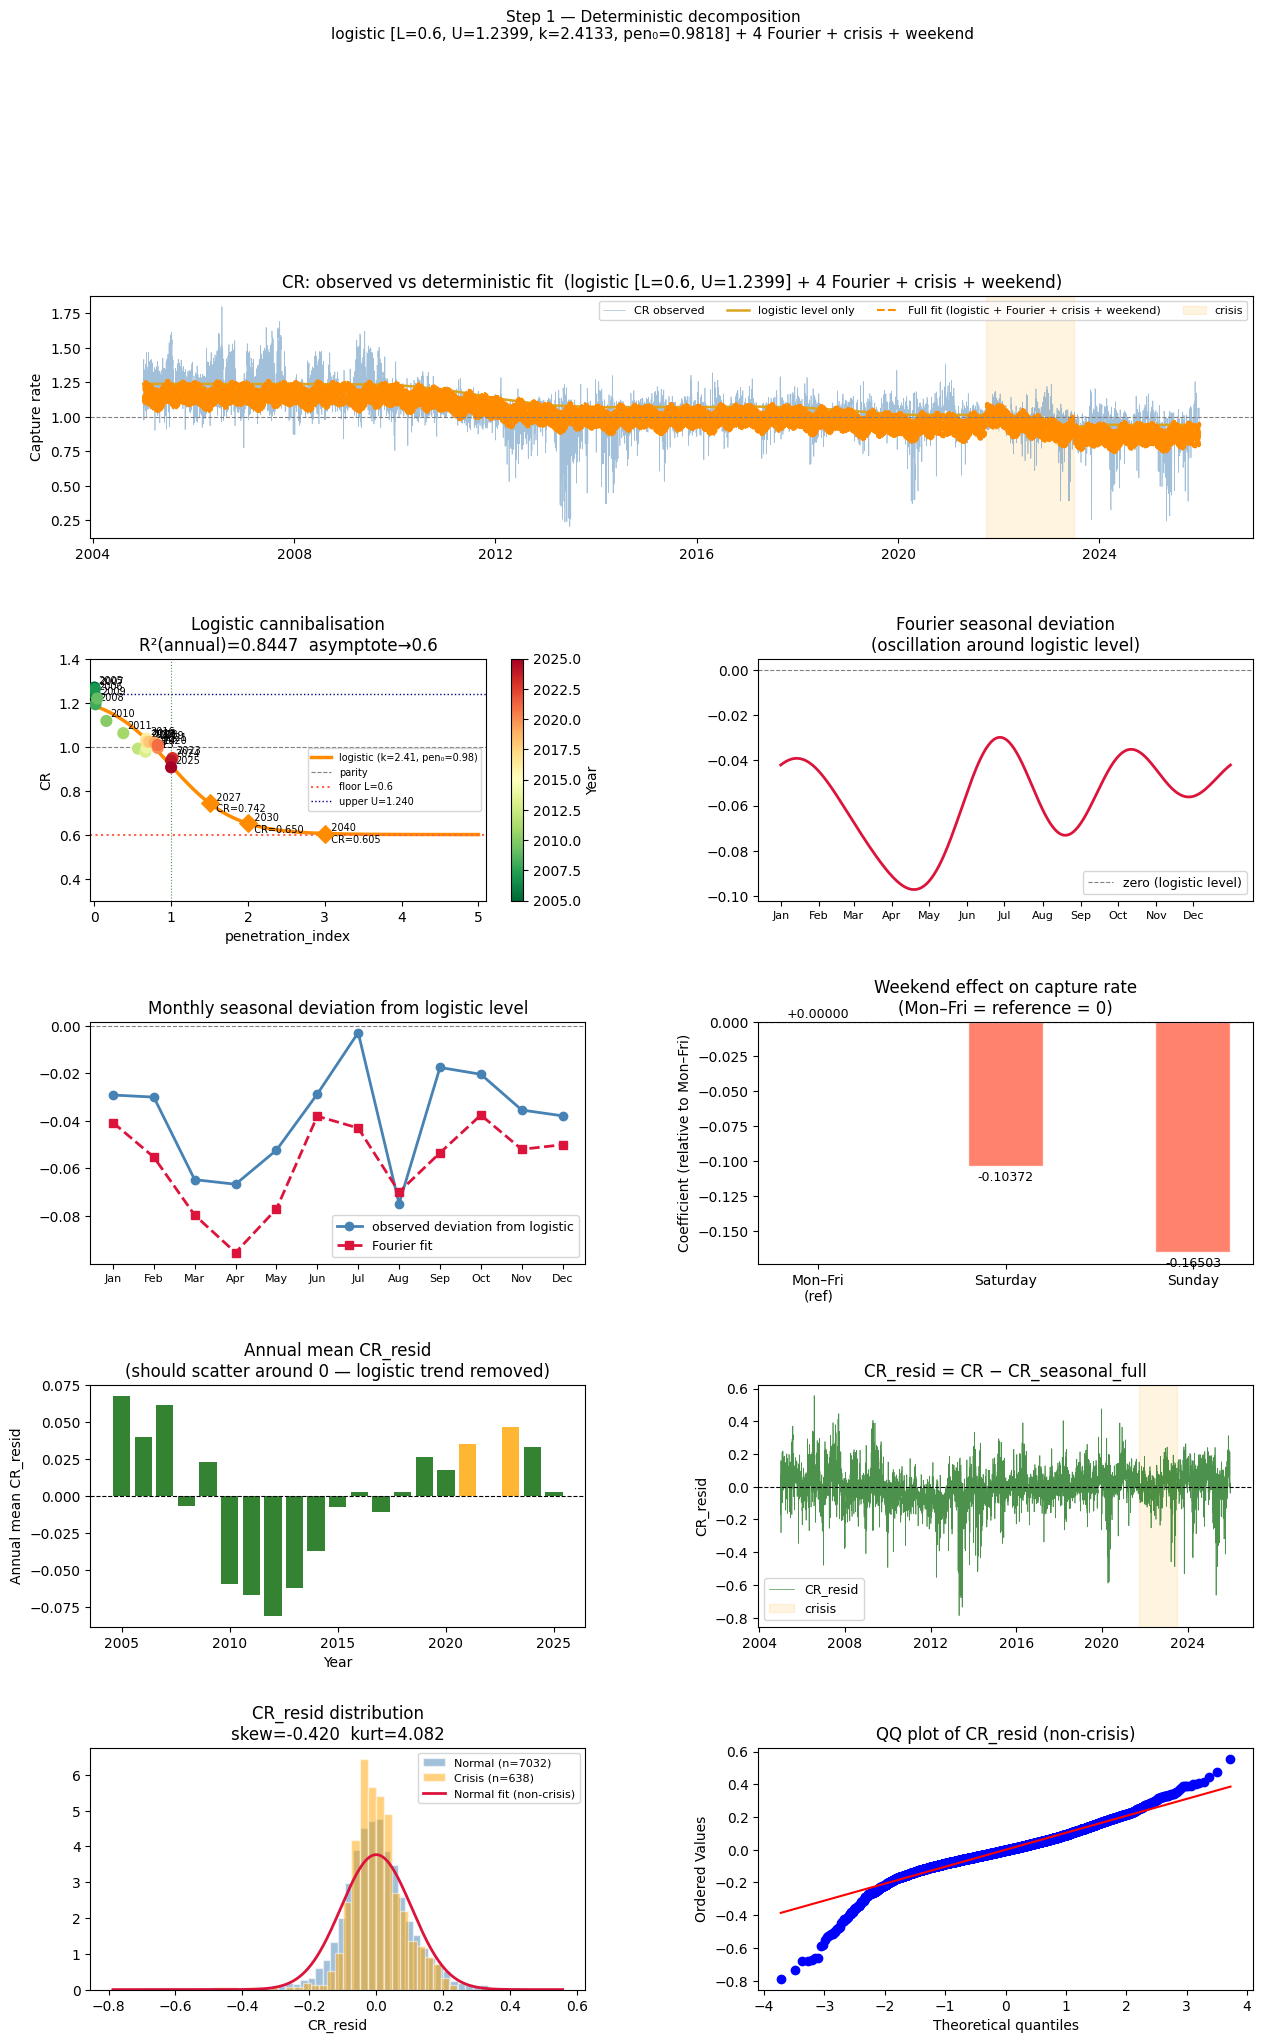

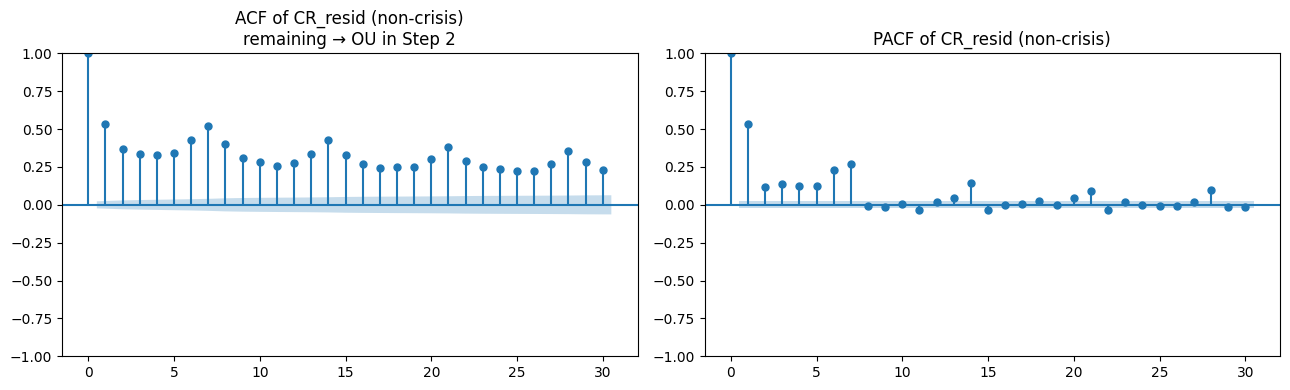


── Step 1 diagnostics (non-crisis CR_resid) ─────────────────────

  ADF stationarity:
    stat=-6.5671  p=0.0000  crit5%=-2.862  ✓ stationary

  Ljung-Box (H0: no autocorrelation):
    lag= 1  p=0.0000  ✗
    lag= 5  p=0.0000  ✗
    lag= 7  p=0.0000  ✗
    lag=14  p=0.0000  ✗
    lag=21  p=0.0000  ✗

  Jarque-Bera: p=0.0000  non-normal

  Summary stats (non-crisis):
    mean  = -0.000000
    std   = 0.105842
    skew  = -0.4196
    kurt  = 4.0821  (excess)


In [ ]:
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────
 
fig = plt.figure(figsize=(15, 22))
gs  = plt.GridSpec(5, 2, figure=fig, hspace=0.50, wspace=0.35)
 
# ── panel 1: CR observed vs fitted ───────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(s_df["date"], s_df["capture_rate"],
        lw=0.5, color="steelblue", alpha=0.5, label="CR observed")
ax.plot(s_df["date"], s_df["CR_logistic"],
        lw=1.8, color="goldenrod", label="logistic level only")
ax.plot(s_df["date"], s_df["CR_seasonal_full"],
        lw=1.5, color="darkorange", ls="--",
        label="Full fit (logistic + Fourier + crisis + weekend)")
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
ax.axvspan(pd.Timestamp(CRISIS_START), pd.Timestamp(CRISIS_END),
           alpha=0.12, color="orange", label="crisis")
ax.set_ylabel("Capture rate")
ax.legend(fontsize=8, ncol=5)
ax.set_title(
    f"CR: observed vs deterministic fit  "
    f"(logistic [L={L_FIXED}, U={U_FIXED:.4f}] + "
    f"{N_HARMONICS} Fourier + crisis + weekend)"
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
# ── panel 2: logistic curve + forward extrapolation ──────────────────────────
ax = fig.add_subplot(gs[1, 0])
pen_line = np.linspace(0, 5.0, 500)
cr_log_curve = logistic(pen_line, k_fit, pen0_fit)
 
sc = ax.scatter(
    ann_agg["pen_mean"], ann_agg["cr_mean"],
    c=ann_agg["year"], cmap="RdYlGn_r", s=60, zorder=5
)
plt.colorbar(sc, ax=ax, label="Year")
for _, row in ann_agg.iterrows():
    ax.annotate(str(int(row["year"])),
                (row["pen_mean"], row["cr_mean"]),
                fontsize=7, xytext=(3,3),
                textcoords="offset points")
 
ax.plot(pen_line, cr_log_curve, color="darkorange", lw=2.5,
        label=f"logistic (k={k_fit:.2f}, pen₀={pen0_fit:.2f})")
ax.axhline(1.0,      color="black",  lw=0.8, ls="--", alpha=0.5,
           label="parity")
ax.axhline(L_FIXED,  color="tomato", lw=1.5, ls=":",
           label=f"floor L={L_FIXED}")
ax.axhline(U_FIXED,  color="navy",   lw=1.0, ls=":",
           label=f"upper U={U_FIXED:.3f}")
ax.axvline(1.0, color="darkgreen", lw=0.8, ls=":", alpha=0.7)
 
for pen_v, yr_l in [(1.5,"2027"),(2.0,"2030"),(3.0,"2040")]:
    cr_v = logistic(pen_v, k_fit, pen0_fit)
    ax.scatter(pen_v, cr_v, s=80, color="darkorange",
               zorder=6, marker="D")
    ax.annotate(f"  {yr_l}\n  CR={cr_v:.3f}",
                (pen_v, cr_v), fontsize=7, va="center")
 
ax.set_xlabel("penetration_index")
ax.set_ylabel("CR")
ax.legend(fontsize=7)
ax.set_title(f"Logistic cannibalisation\n"
             f"R²(annual)={r2_logistic:.4f}  "
             f"asymptote→{L_FIXED}")
ax.set_xlim(-0.05, 5.1)
ax.set_ylim(0.3, 1.4)
 
# ── panel 3: Fourier seasonal deviation ──────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
t_smooth = np.linspace(0, 1, 365)
X_smooth = np.column_stack(
    [np.ones(365)] +                          # intercept — matches X_fourier
    [f(2*np.pi*k*t_smooth)
     for k in range(1, N_HARMONICS+1)
     for f in (np.cos, np.sin)]
)
fourier_smooth = X_smooth @ beta_fourier
doy_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
ax.plot(np.arange(1, 366), fourier_smooth, color="crimson", lw=2)
ax.axhline(0, color="grey", lw=0.8, ls="--",
           label="zero (logistic level)")
ax.set_xticks(doy_ticks)
ax.set_xticklabels(month_names, fontsize=8)
ax.legend(fontsize=9)
ax.set_title("Fourier seasonal deviation\n"
             "(oscillation around logistic level)")
 
# ── panel 4: monthly mean Fourier deviation ───────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
monthly_obs_dev = (
    s_df[s_df["crisis"]==0]
    .assign(CR_dev=lambda x: x["capture_rate"] - x["CR_logistic"])
    .groupby("month")["CR_dev"]
    .mean()
)
ax.plot(range(1,13), monthly_obs_dev.values,
        "o-", color="steelblue", lw=2, ms=6,
        label="observed deviation from logistic")
ax.plot(range(1,13), monthly_fourier.values,
        "s--", color="crimson", lw=2, ms=6,
        label="Fourier fit")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names, fontsize=8)
ax.legend(fontsize=9)
ax.set_title("Monthly seasonal deviation from logistic level")
 
# ── panel 5: weekend effect ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
categories  = ["Mon–Fri\n(ref)", "Saturday", "Sunday"]
coef_values = [0.0, float(beta_saturday), float(beta_sunday)]
colors_wd   = ["steelblue" if v >= 0 else "tomato" for v in coef_values]
ax.bar(categories, coef_values, color=colors_wd,
       alpha=0.8, edgecolor="white", width=0.4)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_ylabel("Coefficient (relative to Mon–Fri)")
ax.set_title("Weekend effect on capture rate\n"
             "(Mon–Fri = reference = 0)")
for i, v in enumerate(coef_values):
    ax.text(i, v + 0.001 if v >= 0 else v - 0.003,
            f"{v:+.5f}", ha="center",
            va="bottom" if v >= 0 else "top", fontsize=9)
 
# ── panel 6: annual mean CR_resid ─────────────────────────────────────────────
ax = fig.add_subplot(gs[3, 0])
colors_bar = [
    "orange" if 2021 <= yr <= 2023 else "darkgreen"
    for yr in ann_resid.index
]
ax.bar(ann_resid.index, ann_resid.values, color=colors_bar, alpha=0.8)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Year")
ax.set_ylabel("Annual mean CR_resid")
ax.set_title("Annual mean CR_resid\n"
             "(should scatter around 0 — logistic trend removed)")
 
# ── panel 7: CR_resid over time ───────────────────────────────────────────────
ax = fig.add_subplot(gs[3, 1])
ax.plot(s_df["date"], s_df["CR_resid"],
        lw=0.5, color="darkgreen", alpha=0.7, label="CR_resid")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvspan(pd.Timestamp(CRISIS_START), pd.Timestamp(CRISIS_END),
           alpha=0.12, color="orange", label="crisis")
ax.set_ylabel("CR_resid")
ax.legend(fontsize=9)
ax.set_title("CR_resid = CR − CR_seasonal_full")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
# ── panel 8: distribution ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[4, 0])
ax.hist(resid_nc, bins=60, density=True, color="steelblue",
        alpha=0.5, edgecolor="white", label=f"Normal (n={len(resid_nc)})")
ax.hist(resid_cr, bins=30, density=True, color="orange",
        alpha=0.5, edgecolor="white", label=f"Crisis (n={len(resid_cr)})")
x_g = np.linspace(s_df["CR_resid"].min(), s_df["CR_resid"].max(), 300)
ax.plot(x_g, stats.norm.pdf(x_g, resid_nc.mean(), resid_nc.std()),
        color="crimson", lw=2, label="Normal fit (non-crisis)")
ax.legend(fontsize=8)
ax.set_title(f"CR_resid distribution\n"
             f"skew={stats.skew(resid_nc):.3f}  "
             f"kurt={stats.kurtosis(resid_nc):.3f}")
ax.set_xlabel("CR_resid")
 
# ── panel 9: QQ plot ──────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[4, 1])
probplot(resid_nc, dist="norm", plot=ax)
ax.set_title("QQ plot of CR_resid (non-crisis)")
 
plt.suptitle(
    f"Step 1 — Deterministic decomposition\n"
    f"logistic [L={L_FIXED}, U={U_FIXED:.4f}, "
    f"k={k_fit:.4f}, pen₀={pen0_fit:.4f}] + "
    f"{N_HARMONICS} Fourier + crisis + weekend",
    fontsize=11, y=1.01
)
plt.show()
 
# ── ACF / PACF ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( resid_nc, lags=30, ax=axes[0])
axes[0].set_title("ACF of CR_resid (non-crisis)\n")
plot_pacf(resid_nc, lags=30, ax=axes[1])
axes[1].set_title("PACF of CR_resid (non-crisis)")
plt.tight_layout()
plt.show()
 
# ─────────────────────────────────────────────────────────────────────────────
# FORMAL DIAGNOSTICS
# ─────────────────────────────────────────────────────────────────────────────
 
print("\n── Step 1 diagnostics (non-crisis CR_resid) ─────────────────────")
 
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(resid_nc, autolag="AIC")
print(f"\n  ADF stationarity:")
print(f"    stat={adf_stat:.4f}  p={adf_p:.4f}  "
      f"crit5%={adf_crit['5%']:.3f}  "
      f"{'✓ stationary' if adf_p < 0.05 else '✗ non-stationary'}")
 
lb = acorr_ljungbox(resid_nc, lags=[1, 5, 7, 14, 21], return_df=True)
print(f"\n  Ljung-Box (H0: no autocorrelation):")
for lag, row in lb.iterrows():
    sig = "✓" if row["lb_pvalue"] > 0.05 else "✗"
    print(f"    lag={lag:2d}  p={row['lb_pvalue']:.4f}  {sig}")
 
jb_stat, jb_p = jarque_bera(resid_nc)
print(f"\n  Jarque-Bera: p={jb_p:.4f}  "
      f"{'approx normal' if jb_p > 0.05 else 'non-normal'}")
 
print(f"\n  Summary stats (non-crisis):")
print(f"    mean  = {resid_nc.mean():.6f}")
print(f"    std   = {resid_nc.std():.6f}")
print(f"    skew  = {stats.skew(resid_nc):.4f}")
print(f"    kurt  = {stats.kurtosis(resid_nc):.4f}  (excess)")

# Stochastic process - AR (1-7)

── Step 1F: AR(1–7) pre-filter ──────────────────────────────────
  Input  : s_df['CR_resid']  n=7670

  PACF of CR_resid (significance threshold = ±0.0224):
    lag= 0  r=+1.0000
    lag= 1  r=+0.5323 ← significant
    lag= 2  r=+0.1199 ← significant
    lag= 3  r=+0.1352 ← significant
    lag= 4  r=+0.1231 ← significant
    lag= 5  r=+0.1179 ← significant
    lag= 6  r=+0.2264 ← significant
    lag= 7  r=+0.2647 ← significant
    lag= 8  r=-0.0145
    lag= 9  r=-0.0156
    lag=10  r=+0.0021
    lag=11  r=-0.0314 ← significant
    lag=12  r=+0.0238 ← significant
    lag=13  r=+0.0505 ← significant
    lag=14  r=+0.1357 ← significant

  AR(1–7) fit (n=7663):
  R² = 0.4069

  Coef                      φ        se        t  sig
  ----------------  ---------  --------  -------  ---
  CR_resid(t-1)      +0.33526   0.01102    30.42  ***
  CR_resid(t-2)      +0.01815   0.01157     1.57  n.s.
  CR_resid(t-3)      +0.04099   0.01156     3.54  ***
  CR_resid(t-4)      +0.04747   0.01156     4.1

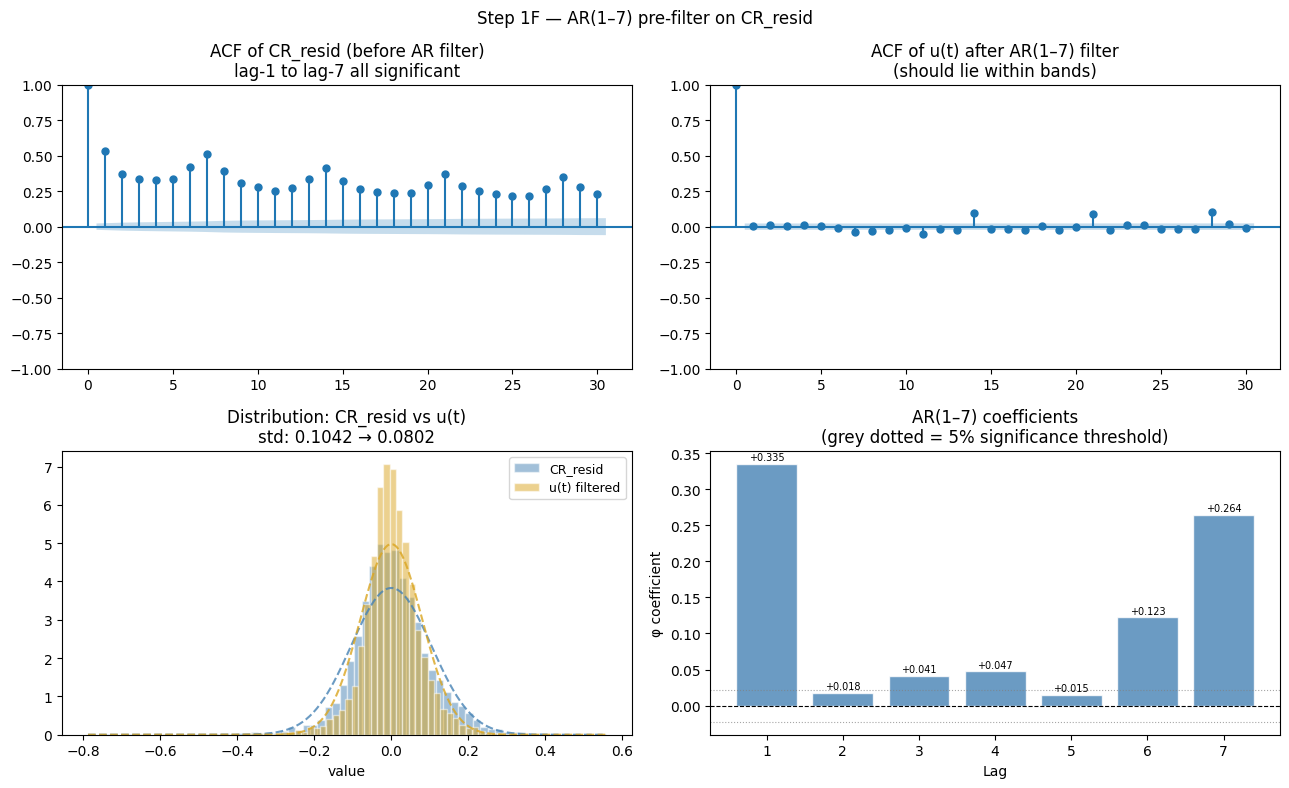


── Step 1F complete ─────────────────────────────────────────────
  AR(7) coefficients:
    φ1 = +0.33526
    φ2 = +0.01815
    φ3 = +0.04099
    φ4 = +0.04747
    φ5 = +0.01492
    φ6 = +0.12260
    φ7 = +0.26436

  Input  to Step 2 : u(t)  n=7663  std=0.08018
  Note: first 7 obs dropped due to AR lag structure

  Forward simulation structure:
    CR_resid(t) = φ1·CR_resid(t-1) + φ2·CR_resid(t-2) + φ3·CR_resid(t-3) + φ4·CR_resid(t-4) + φ5·CR_resid(t-5) + φ6·CR_resid(t-6) + φ7·CR_resid(t-7) + u(t)
    u(t) ~ OU(κ, σ_cr, t(ν))  ← Step 2

  Variables ready for Step 2:
    u_vals    — AR-filtered residual (OU input)
    dates_ar  — aligned dates
    crisis_ar — aligned crisis flag
    phi       — AR coefficients array φ₁..φ₇


In [ ]:
# STEP 2 — AR(1–7) pre-filter: remove weekly autocorrelation structure
# ─────────────────────────────────────────────────────────────────────────────
# PACF of CR_resid shows all lags 1–7 significant (r = +0.12 to +0.53).
# AR(1,7) was insufficient — lags 2–6 also carry predictive information.
# AR(1–7) includes all lags 1 through 7 simultaneously.
#
# Model: CR_resid(t) = φ₁·CR_resid(t-1) + ... + φ₇·CR_resid(t-7) + u(t)
#
# u(t) = AR-filtered residual — clean input for OU estimation in Step 2
#
# Forward simulation uses:
#   CR_resid_sim(t) = φ₁·CR_resid_sim(t-1) + ... + φ₇·CR_resid_sim(t-7)
#                   + OU_innovation(t)
 
from statsmodels.tsa.stattools import pacf as pacf_func
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf
 
cr_resid_vals = s_df["CR_resid"].values
n_cr          = len(cr_resid_vals)
N_AR_LAGS     = 7
 
print("── Step 1F: AR(1–7) pre-filter ──────────────────────────────────")
print(f"  Input  : s_df['CR_resid']  n={n_cr}")
 
# ── PACF diagnostic ───────────────────────────────────────────────────────────
pacf_vals = pacf_func(cr_resid_vals, nlags=14, method="ywm")
ci_bound  = 1.96 / np.sqrt(n_cr)
 
print(f"\n  PACF of CR_resid (significance threshold = ±{ci_bound:.4f}):")
for lag, v in enumerate(pacf_vals):
    sig = " ← significant" if abs(v) > ci_bound and lag > 0 else ""
    print(f"    lag={lag:2d}  r={v:+.4f}{sig}")
 
# ── build AR(1–7) design matrix ───────────────────────────────────────────────
start = N_AR_LAGS
y_ar  = cr_resid_vals[start:]
X_ar  = np.column_stack([
    cr_resid_vals[start-i: n_cr-i]
    for i in range(1, N_AR_LAGS + 1)
])
col_names_ar = [f"CR_resid(t-{i})" for i in range(1, N_AR_LAGS + 1)]
 
# ── OLS without intercept (CR_resid is mean-zero) ─────────────────────────────
phi, _, _, _ = np.linalg.lstsq(X_ar, y_ar, rcond=None)
 
y_hat_ar  = X_ar @ phi
u_vals    = y_ar - y_hat_ar
n_ar      = len(y_ar)
 
ss_res_ar = np.sum(u_vals**2)
ss_tot_ar = np.sum((y_ar - y_ar.mean())**2)
r2_ar     = 1 - ss_res_ar / ss_tot_ar
 
# standard errors
s2_ar    = np.sum(u_vals**2) / (n_ar - N_AR_LAGS)
XtX_inv  = np.linalg.inv(X_ar.T @ X_ar)
se_phi   = np.sqrt(np.diag(s2_ar * XtX_inv))
t_phi    = phi / se_phi
p_phi    = 2 * (1 - stats.t.cdf(np.abs(t_phi), df=n_ar - N_AR_LAGS))
 
print(f"\n  AR(1–{N_AR_LAGS}) fit (n={n_ar}):")
print(f"  R² = {r2_ar:.4f}")
print(f"\n  {'Coef':<16}  {'φ':>9}  {'se':>8}  {'t':>7}  sig")
print(f"  {'-'*16}  {'-'*9}  {'-'*8}  {'-'*7}  ---")
for name, p, se, t_s, pv in zip(col_names_ar, phi, se_phi, t_phi, p_phi):
    sig = "***" if pv<0.001 else "**" if pv<0.01 else "*" if pv<0.05 else "n.s."
    print(f"  {name:<16}  {p:>+9.5f}  {se:>8.5f}  {t_s:>7.2f}  {sig}")
 
# ── Ljung-Box on u(t) ─────────────────────────────────────────────────────────
lb_u = acorr_ljungbox(u_vals, lags=[1, 5, 7, 14, 21], return_df=True)
print(f"\n  Ljung-Box on u(t) after AR(1–{N_AR_LAGS}) filter:")
for lag, row in lb_u.iterrows():
    sig = "✓" if row["lb_pvalue"] > 0.05 else "✗"
    print(f"    lag={lag:2d}  p={row['lb_pvalue']:.4f}  {sig}")
 
# ── ARCH-LM on u(t) ───────────────────────────────────────────────────────────
arch_stat, arch_p, _, _ = het_arch(u_vals, nlags=5)
print(f"\n  ARCH-LM on u(t):")
print(f"    stat={arch_stat:.3f}  p={arch_p:.4f}  "
      f"{'✓ no ARCH' if arch_p > 0.05 else '✗ ARCH present (noted as limitation)'}")
 
# ── u(t) summary stats ────────────────────────────────────────────────────────
print(f"\n  AR-filtered residual u(t):")
print(f"    n      = {n_ar}")
print(f"    mean   = {u_vals.mean():.6f}  (should be ≈ 0)")
print(f"    std    = {u_vals.std():.6f}")
print(f"    skew   = {stats.skew(u_vals):.4f}")
print(f"    kurt   = {stats.kurtosis(u_vals):.4f}  (excess)")
 
# ── ADF stationarity check ────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(u_vals, autolag="AIC")
print(f"\n  ADF stationarity on u(t):")
print(f"    stat={adf_stat:.4f}  p={adf_p:.4f}  "
      f"crit5%={adf_crit['5%']:.3f}  "
      f"{'✓ stationary' if adf_p < 0.05 else '✗ non-stationary'}")
 
# ── store aligned arrays for Step 2 ──────────────────────────────────────────
dates_ar   = s_df["date"].values[start:]
crisis_ar  = s_df["crisis"].values[start:].astype(bool)
 
s_df_ar = pd.DataFrame({
    "date":    pd.to_datetime(dates_ar),
    "u":       u_vals,
    "crisis":  crisis_ar.astype(int),
    "year":    pd.to_datetime(dates_ar).year,
    "month":   pd.to_datetime(dates_ar).month,
    "weekday": pd.to_datetime(dates_ar).weekday,
})
 
# ── plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
 
# ACF before filter
plot_acf(cr_resid_vals, lags=30, ax=axes[0, 0])
axes[0, 0].set_title("ACF of CR_resid (before AR filter)\n"
                      "lag-1 to lag-7 all significant")
 
# ACF after filter
plot_acf(u_vals, lags=30, ax=axes[0, 1])
axes[0, 1].set_title(f"ACF of u(t) after AR(1–{N_AR_LAGS}) filter\n"
                     "(should lie within bands)")
 
# distribution comparison
ax = axes[1, 0]
ax.hist(cr_resid_vals, bins=70, density=True, color="steelblue",
        alpha=0.5, edgecolor="white", label="CR_resid")
ax.hist(u_vals, bins=70, density=True, color="goldenrod",
        alpha=0.5, edgecolor="white", label="u(t) filtered")
x_g = np.linspace(min(cr_resid_vals.min(), u_vals.min()),
                  max(cr_resid_vals.max(), u_vals.max()), 300)
ax.plot(x_g, stats.norm.pdf(x_g, 0, cr_resid_vals.std()),
        color="steelblue", lw=1.5, ls="--", alpha=0.8)
ax.plot(x_g, stats.norm.pdf(x_g, 0, u_vals.std()),
        color="goldenrod", lw=1.5, ls="--", alpha=0.8)
ax.legend(fontsize=9)
ax.set_title("Distribution: CR_resid vs u(t)\n"
             f"std: {cr_resid_vals.std():.4f} → {u_vals.std():.4f}")
ax.set_xlabel("value")
 
# AR coefficients bar chart
ax = axes[1, 1]
colors_phi = ["steelblue" if p > 0 else "tomato" for p in phi]
ax.bar(range(1, N_AR_LAGS+1), phi, color=colors_phi,
       alpha=0.8, edgecolor="white")
ax.axhline(0, color="black", lw=0.8, ls="--")
# significance bands
ax.axhline( ci_bound, color="grey", lw=0.8, ls=":", alpha=0.7)
ax.axhline(-ci_bound, color="grey", lw=0.8, ls=":", alpha=0.7)
ax.set_xlabel("Lag")
ax.set_ylabel("φ coefficient")
ax.set_xticks(range(1, N_AR_LAGS+1))
ax.set_title(f"AR(1–{N_AR_LAGS}) coefficients\n"
             "(grey dotted = 5% significance threshold)")
for i, (p, t_s) in enumerate(zip(phi, t_phi), start=1):
    ax.text(i, p + 0.005 if p > 0 else p - 0.010,
            f"{p:+.3f}", ha="center", fontsize=7)
 
plt.suptitle(f"Step 1F — AR(1–{N_AR_LAGS}) pre-filter on CR_resid",
             fontsize=12)
plt.tight_layout()
plt.show()
 
# ── summary ───────────────────────────────────────────────────────────────────
print(f"\n── Step 1F complete ─────────────────────────────────────────────")
print(f"  AR({N_AR_LAGS}) coefficients:")
for i, p in enumerate(phi, start=1):
    print(f"    φ{i} = {p:+.5f}")
print(f"\n  Input  to Step 2 : u(t)  n={n_ar}  std={u_vals.std():.5f}")
print(f"  Note: first {start} obs dropped due to AR lag structure")
print(f"\n  Forward simulation structure:")
print(f"    CR_resid(t) = " +
      " + ".join([f"φ{i}·CR_resid(t-{i})" for i in range(1, N_AR_LAGS+1)]) +
      " + u(t)")
print(f"    u(t) ~ OU(κ, σ_cr, t(ν))  ← Step 2")
print(f"\n  Variables ready for Step 2:")
print(f"    u_vals    — AR-filtered residual (OU input)")
print(f"    dates_ar  — aligned dates")
print(f"    crisis_ar — aligned crisis flag")
print(f"    phi       — AR coefficients array φ₁..φ₇")


In [110]:
# STEP 2A — Descriptive analysis of u(t)
# ─────────────────────────────────────────────────────────────────────────────
# u(t) is the innovation of the AR(1–7) model — the unpredictable daily
# surprise after removing the weekly autocorrelation structure.
# It should be approximately i.i.d. apart from the heavy tails.
 
print("── Step 2A: Innovation series u(t) ─────────────────────────────")
print(f"  Source   : AR(1–7) residuals from Step 1F")
print(f"  n total  : {len(u_vals)}")
print(f"  n normal : {(~crisis_ar).sum()}")
print(f"  n crisis : {crisis_ar.sum()}")
 
u_normal = u_vals[~crisis_ar]
u_crisis = u_vals[ crisis_ar]
 
print(f"\n  {'Statistic':<12}  {'All':>10}  {'Normal':>10}  {'Crisis':>10}")
print(f"  {'-'*12}  {'-'*10}  {'-'*10}  {'-'*10}")
for name, fn in [
    ("mean",  np.mean),
    ("std",   np.std),
    ("skew",  stats.skew),
    ("kurt",  stats.kurtosis),
    ("p5",    lambda x: np.percentile(x,  5)),
    ("p25",   lambda x: np.percentile(x, 25)),
    ("p75",   lambda x: np.percentile(x, 75)),
    ("p95",   lambda x: np.percentile(x, 95)),
]:
    print(f"  {name:<12}  {fn(u_vals):>10.5f}  "
          f"{fn(u_normal):>10.5f}  {fn(u_crisis):>10.5f}")
 
# confirm u(t) is approximately uncorrelated (white noise in mean)
lb_u = acorr_ljungbox(u_vals, lags=[1, 5, 7, 14], return_df=True)
print(f"\n  Ljung-Box on u(t) — should be white noise in mean:")
for lag, row in lb_u.iterrows():
    sig = "✓" if row["lb_pvalue"] > 0.05 else "✗"
    print(f"    lag={lag:2d}  p={row['lb_pvalue']:.4f}  {sig}")
 
arch_stat, arch_p, _, _ = het_arch(u_vals, nlags=5)
print(f"\n  ARCH-LM on u(t):")
print(f"    p={arch_p:.4f}  "
      f"{'✓ no conditional heteroscedasticity' if arch_p > 0.05 else '✗ ARCH present (noted as limitation)'}")
 
jb_stat, jb_p = jarque_bera(u_vals)
print(f"\n  Jarque-Bera normality test:")
print(f"    p={jb_p:.4f}  "
      f"{'normal' if jb_p > 0.05 else 'non-normal → t distribution warranted'}")
 

── Step 2A: Innovation series u(t) ─────────────────────────────
  Source   : AR(1–7) residuals from Step 1F
  n total  : 7663
  n normal : 7025
  n crisis : 638

  Statistic            All      Normal      Crisis
  ------------  ----------  ----------  ----------
  mean             0.00001     0.00002    -0.00015
  std              0.08018     0.08110     0.06932
  skew            -0.70422    -0.66576    -1.35523
  kurt             6.31892     6.12819     9.08919
  p5              -0.11680    -0.11893    -0.09405
  p25             -0.03787    -0.03812    -0.03517
  p75              0.04047     0.04057     0.03889
  p95              0.12247     0.12341     0.09959

  Ljung-Box on u(t) — should be white noise in mean:
    lag= 1  p=0.7428  ✓
    lag= 5  p=0.8944  ✓
    lag= 7  p=0.0555  ✓
    lag=14  p=0.0000  ✗

  ARCH-LM on u(t):
    p=0.0000  ✗ ARCH present (noted as limitation)

  Jarque-Bera normality test:
    p=0.0000  non-normal → t distribution warranted


In [111]:
# STEP 2B — MLE grid search for best ν
# ─────────────────────────────────────────────────────────────────────────────
 
def t_loglikelihood(nu, residuals):
    """
    Log-likelihood under zero-mean t(ν).
    Scale set to match sample variance: σ·√((ν-2)/ν).
    """
    if nu <= 2:
        return -1e10
    std_r = residuals.std(ddof=1)
    scale = std_r * np.sqrt((nu - 2) / nu)
    return float(np.sum(t_dist.logpdf(residuals, df=nu, loc=0, scale=scale)))
 
nu_grid    = np.arange(2.5, 61.0, 0.5)
ll_grid    = [t_loglikelihood(nu, u_vals) for nu in nu_grid]
best_nu_cr = float(nu_grid[np.argmax(ll_grid)])
best_ll_cr = max(ll_grid)
 
# Gaussian log-likelihood
ll_gauss = float(np.sum(stats.norm.logpdf(
    u_vals, loc=0, scale=u_vals.std(ddof=1)
)))
delta_aic = (-2*best_ll_cr + 2) - (-2*ll_gauss)
 
# implied kurtosis from ν
implied_kurt = 6 / (best_nu_cr - 4) if best_nu_cr > 4 else np.inf
 
# scale parameter
sigma_cr  = float(u_vals.std(ddof=1))
scale_t   = sigma_cr * np.sqrt((best_nu_cr - 2) / best_nu_cr) \
            if best_nu_cr > 2 else sigma_cr
 
print(f"\n── Step 2B: MLE ν grid search ───────────────────────────────────")
print(f"  Best ν (MLE)       = {best_nu_cr:.1f}")
print(f"  Scale σ (full)     = {sigma_cr:.6f}")
print(f"  Scale σ_t adjusted = {scale_t:.6f}  (= σ·√((ν-2)/ν))")
print(f"  LL at best ν       = {best_ll_cr:.2f}")
print(f"  LL Gaussian        = {ll_gauss:.2f}")
print(f"  ΔAIC (t−Gaussian)  = {delta_aic:.2f}  "
      f"{'✓ t wins' if delta_aic < -2 else 'Gaussian adequate'}")
print(f"  Implied kurt (ν)   = {implied_kurt:.3f}  "
      f"(observed kurt = {stats.kurtosis(u_vals):.3f})")
 
print(f"\n  Top 5 ν by log-likelihood:")
ll_df = pd.DataFrame({"nu": nu_grid, "ll": ll_grid})
for _, row in ll_df.nlargest(5, "ll").iterrows():
    d_aic = (-2*row["ll"] + 2) - (-2*best_ll_cr + 2)
    print(f"    ν={row['nu']:5.1f}  LL={row['ll']:10.2f}  "
          f"ΔAIC={d_aic:+.2f}")
 
# ν decision: MLE vs copula
try:
    diff_nu = abs(best_nu_cr - best_nu)
    if diff_nu <= 5:
        nu_cr = int(best_nu)
        print(f"\n  ν decision: copula ν={best_nu}  MLE ν={best_nu_cr:.1f}  "
              f"diff={diff_nu:.1f} ≤ 5")
        print(f"  → use copula ν={nu_cr} for architectural consistency")
    else:
        nu_cr = int(round(best_nu_cr))
        print(f"\n  ν decision: copula ν={best_nu}  MLE ν={best_nu_cr:.1f}  "
              f"diff={diff_nu:.1f} > 5")
        print(f"  → use MLE ν={nu_cr} (tails differ materially from copula)")
except NameError:
    nu_cr = int(round(best_nu_cr))
    print(f"\n  Copula ν not in memory — using MLE ν={nu_cr}")
 
# scale adjusted to chosen ν
scale_t_final = sigma_cr * np.sqrt((nu_cr - 2) / nu_cr) \
                if nu_cr > 2 else sigma_cr

NameError: name 't_dist' is not defined


── Step 2C: Distribution diagnostics ───────────────────────────
  t(ν=4) vs Gaussian comparison:
  Quantile      Observed    Gaussian        t(ν)
  ----------  ----------  ----------  ----------
  p1           -0.24827    -0.18654    -0.21245
  p5           -0.11680    -0.13189    -0.12088
  p10          -0.07835    -0.10276    -0.08693
  p25          -0.03787    -0.05408    -0.04200
  p50          -0.00068     0.00000     0.00000
  p75           0.04047     0.05408     0.04200
  p90           0.08715     0.10276     0.08693
  p95           0.12247     0.13189     0.12088
  p99           0.20778     0.18654     0.21245


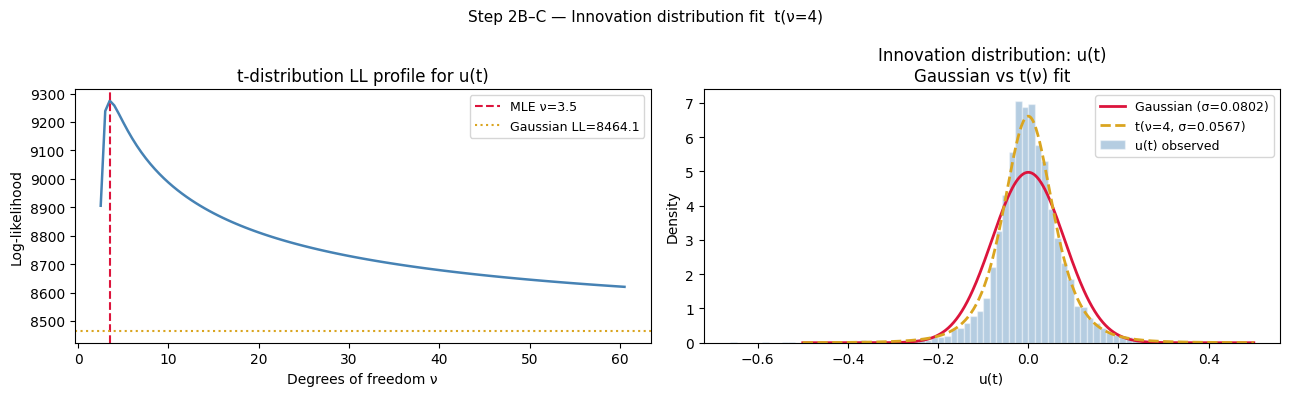

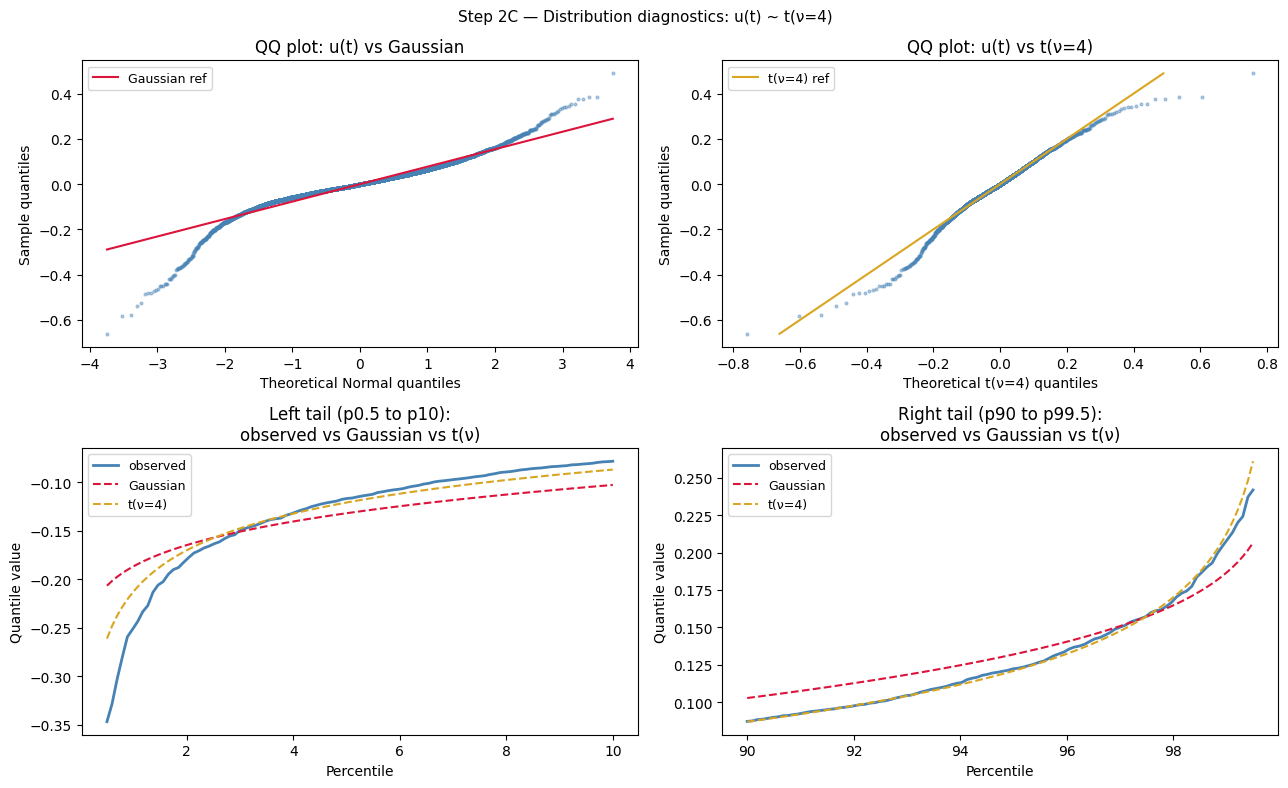

In [ ]:
# STEP 2C — Distribution diagnostics: Gaussian vs t(ν) comparison
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 2C: Distribution diagnostics ───────────────────────────")
print(f"  t(ν={nu_cr}) vs Gaussian comparison:")
print(f"  {'Quantile':<10}  {'Observed':>10}  {'Gaussian':>10}  {'t(ν)':>10}")
print(f"  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}")
for pct in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    obs_q  = float(np.percentile(u_vals, pct))
    gauss_q = float(stats.norm.ppf(pct/100, loc=0, scale=sigma_cr))
    t_q    = float(t_dist.ppf(pct/100, df=nu_cr, loc=0, scale=scale_t_final))
    print(f"  p{pct:<8}  {obs_q:>10.5f}  {gauss_q:>10.5f}  {t_q:>10.5f}")
 
# LL profile plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
ax = axes[0]
ax.plot(nu_grid, ll_grid, lw=1.8, color="steelblue")
ax.axvline(best_nu_cr, color="crimson", lw=1.5, ls="--",
           label=f"MLE ν={best_nu_cr:.1f}")
ax.axhline(ll_gauss, color="goldenrod", lw=1.5, ls=":",
           label=f"Gaussian LL={ll_gauss:.1f}")
try:
    ax.axvline(best_nu, color="darkgreen", lw=1.5, ls="-.",
               label=f"copula ν={best_nu}")
except NameError:
    pass
if nu_cr != int(round(best_nu_cr)):
    ax.axvline(nu_cr, color="purple", lw=1.5, ls="-.",
               label=f"chosen ν={nu_cr}")
ax.set_xlabel("Degrees of freedom ν")
ax.set_ylabel("Log-likelihood")
ax.set_title("t-distribution LL profile for u(t)")
ax.legend(fontsize=9)
 
# tail probability comparison
ax = axes[1]
x_tail = np.linspace(-0.5, 0.5, 500)
ax.plot(x_tail, stats.norm.pdf(x_tail, 0, sigma_cr),
        color="crimson", lw=2, label=f"Gaussian (σ={sigma_cr:.4f})")
ax.plot(x_tail, t_dist.pdf(x_tail, df=nu_cr, loc=0, scale=scale_t_final),
        color="goldenrod", lw=2, ls="--",
        label=f"t(ν={nu_cr}, σ={scale_t_final:.4f})")
ax.hist(u_vals, bins=80, density=True, color="steelblue",
        alpha=0.4, edgecolor="white", label="u(t) observed")
ax.set_xlabel("u(t)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
ax.set_title("Innovation distribution: u(t)\nGaussian vs t(ν) fit")
 
plt.suptitle(f"Step 2B–C — Innovation distribution fit  t(ν={nu_cr})",
             fontsize=11)
plt.tight_layout()
plt.show()
 
# four-panel diagnostic
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
 
# QQ Gaussian
ax = axes[0, 0]
osm, osr = probplot(u_vals, dist="norm", fit=False)
ax.scatter(osm, osr, s=4, alpha=0.4, color="steelblue")
slope_g, int_g = np.polyfit(osm, osr, 1)
ax.plot(osm, slope_g*np.array(osm) + int_g,
        color="crimson", lw=1.5, label="Gaussian ref")
ax.set_xlabel("Theoretical Normal quantiles")
ax.set_ylabel("Sample quantiles")
ax.legend(fontsize=9)
ax.set_title("QQ plot: u(t) vs Gaussian")
 
# QQ t(ν)
ax = axes[0, 1]
osm_t = t_dist.ppf(stats.norm.cdf(osm), df=nu_cr) * scale_t_final
ax.scatter(osm_t, osr, s=4, alpha=0.4, color="steelblue")
ax.plot([osr.min(), osr.max()],
        [osr.min(), osr.max()],
        color="goldenrod", lw=1.5, label=f"t(ν={nu_cr}) ref")
ax.set_xlabel(f"Theoretical t(ν={nu_cr}) quantiles")
ax.set_ylabel("Sample quantiles")
ax.legend(fontsize=9)
ax.set_title(f"QQ plot: u(t) vs t(ν={nu_cr})")
 
# left tail focus (p1 to p10)
ax = axes[1, 0]
pcts = np.linspace(0.5, 10, 100)
obs_q   = np.percentile(u_vals, pcts)
gauss_q = stats.norm.ppf(pcts/100, 0, sigma_cr)
t_q_arr = t_dist.ppf(pcts/100, df=nu_cr, loc=0, scale=scale_t_final)
ax.plot(pcts, obs_q,   color="steelblue", lw=2, label="observed")
ax.plot(pcts, gauss_q, color="crimson",   lw=1.5, ls="--", label="Gaussian")
ax.plot(pcts, t_q_arr, color="goldenrod", lw=1.5, ls="--",
        label=f"t(ν={nu_cr})")
ax.set_xlabel("Percentile")
ax.set_ylabel("Quantile value")
ax.legend(fontsize=9)
ax.set_title("Left tail (p0.5 to p10):\nobserved vs Gaussian vs t(ν)")
 
# right tail focus (p90 to p99.5)
ax = axes[1, 1]
pcts_r = np.linspace(90, 99.5, 100)
obs_qr   = np.percentile(u_vals, pcts_r)
gauss_qr = stats.norm.ppf(pcts_r/100, 0, sigma_cr)
t_qr_arr = t_dist.ppf(pcts_r/100, df=nu_cr, loc=0, scale=scale_t_final)
ax.plot(pcts_r, obs_qr,   color="steelblue", lw=2, label="observed")
ax.plot(pcts_r, gauss_qr, color="crimson",   lw=1.5, ls="--", label="Gaussian")
ax.plot(pcts_r, t_qr_arr, color="goldenrod", lw=1.5, ls="--",
        label=f"t(ν={nu_cr})")
ax.set_xlabel("Percentile")
ax.set_ylabel("Quantile value")
ax.legend(fontsize=9)
ax.set_title("Right tail (p90 to p99.5):\nobserved vs Gaussian vs t(ν)")
 
plt.suptitle(f"Step 2C — Distribution diagnostics: u(t) ~ t(ν={nu_cr})",
             fontsize=11)
plt.tight_layout()
plt.show()


── Step 2D: Validation — AR(1–7) + t(ν=4) simulation ─────
  N paths : 2000  ×  7670 steps

  Metric          Observed   Simulated
  ------------  ----------  ----------
  mean             -0.0000     -0.0001
  std               0.1042      0.1041
  p5               -0.1532     -0.1642
  p10              -0.1083     -0.1238
  p50              -0.0031     -0.0001
  p90               0.1255      0.1236
  p95               0.1720      0.1638
  skew             -0.4359      0.0376
  kurt              4.1940      6.5708

  KS test: stat=0.0353  p=0.0001  ✗ distributions differ

  ACF comparison (observed vs one simulated path):
   Lag    Observed   Simulated
     1      0.5323      0.5286
     2      0.3692      0.3702
     3      0.3322      0.3447
     4      0.3285      0.3370
     5      0.3350      0.3314
     6      0.4205      0.4178
     7      0.5114      0.5012
    14      0.4165      0.3046


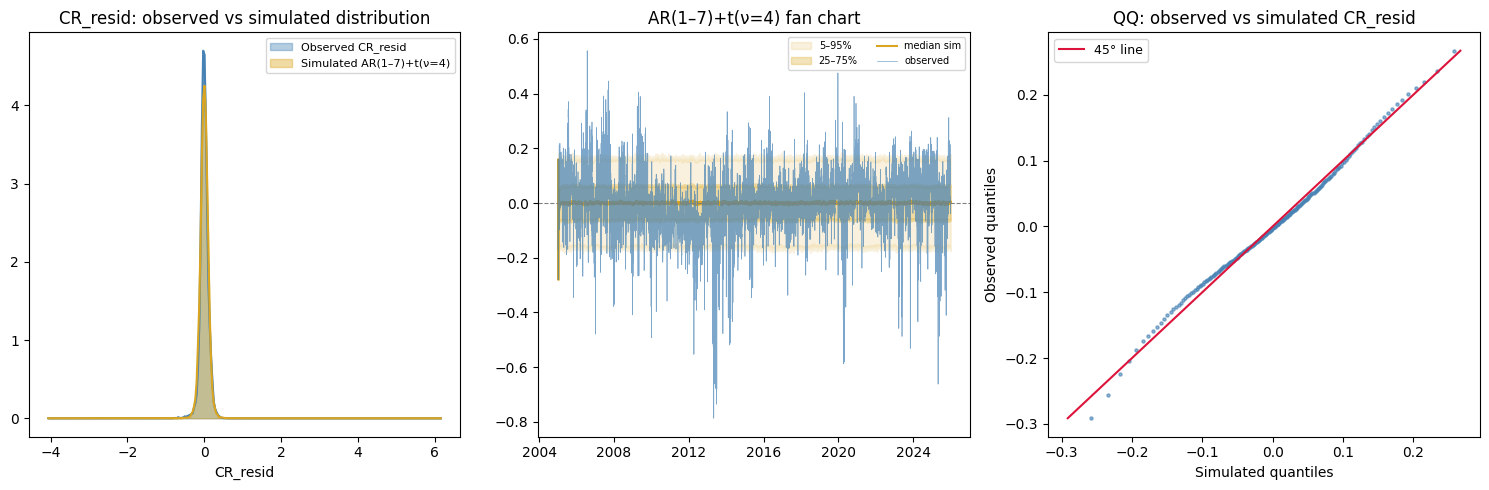

In [ ]:
# STEP 2D — Validation: simulated AR(1–7) paths vs observed CR_resid
# ─────────────────────────────────────────────────────────────────────────────
# Simulate full CR_resid paths using the AR(1–7) + t(ν) model.
# Compare simulated distribution against observed CR_resid.
 
N_SIM     = 2000
cr_resid_all = s_df["CR_resid"].values
n_steps   = len(cr_resid_all)
n_ar_lags = len(phi)   # = 7
np.random.seed(42)
 
cr_sim_paths = np.zeros((N_SIM, n_steps))
 
# initialise with first 7 observed values
cr_sim_paths[:, :n_ar_lags] = cr_resid_all[:n_ar_lags]
 
for step in range(n_ar_lags, n_steps):
    # t(nu_cr) innovations
    z_raw = np.random.standard_normal(N_SIM)
    w     = np.random.chisquare(df=nu_cr, size=N_SIM)
    eps_t = z_raw / np.sqrt(w / nu_cr) * scale_t_final
 
    # AR(1–7) update
    ar_term = np.zeros(N_SIM)
    for i, p in enumerate(phi):
        ar_term += p * cr_sim_paths[:, step - 1 - i]
 
    cr_sim_paths[:, step] = ar_term + eps_t
 
cr_obs_flat = cr_resid_all
cr_sim_flat = cr_sim_paths.ravel()
 
print(f"\n── Step 2D: Validation — AR(1–7) + t(ν={nu_cr}) simulation ─────")
print(f"  N paths : {N_SIM}  ×  {n_steps} steps")
print(f"\n  {'Metric':<12}  {'Observed':>10}  {'Simulated':>10}")
print(f"  {'-'*12}  {'-'*10}  {'-'*10}")
for name, fn in [
    ("mean",   np.mean),
    ("std",    np.std),
    ("p5",     lambda x: np.percentile(x,  5)),
    ("p10",    lambda x: np.percentile(x, 10)),
    ("p50",    lambda x: np.percentile(x, 50)),
    ("p90",    lambda x: np.percentile(x, 90)),
    ("p95",    lambda x: np.percentile(x, 95)),
    ("skew",   stats.skew),
    ("kurt",   stats.kurtosis),
]:
    print(f"  {name:<12}  {fn(cr_obs_flat):>10.4f}  "
          f"{fn(cr_sim_flat):>10.4f}")
 
ks_stat, ks_p = stats.ks_2samp(
    cr_obs_flat,
    np.random.choice(cr_sim_flat, len(cr_obs_flat), replace=False)
)
print(f"\n  KS test: stat={ks_stat:.4f}  p={ks_p:.4f}  "
      f"{'✓ distributions match' if ks_p > 0.05 else '✗ distributions differ'}")
 
# check ACF of one simulated path vs observed
from statsmodels.tsa.stattools import acf as acf_func
acf_obs = acf_func(cr_obs_flat, nlags=14, fft=True)
acf_sim = acf_func(cr_sim_paths[0], nlags=14, fft=True)
print(f"\n  ACF comparison (observed vs one simulated path):")
print(f"  {'Lag':>4}  {'Observed':>10}  {'Simulated':>10}")
for lag in [1, 2, 3, 4, 5, 6, 7, 14]:
    print(f"  {lag:>4}  {acf_obs[lag]:>10.4f}  {acf_sim[lag]:>10.4f}")
 
# validation plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
# KDE comparison
ax = axes[0]
x_plot = np.linspace(
    min(cr_obs_flat.min(), cr_sim_flat.min()) - 0.02,
    max(cr_obs_flat.max(), cr_sim_flat.max()) + 0.02, 300
)
kde_obs = gaussian_kde(cr_obs_flat)
kde_sim = gaussian_kde(
    np.random.choice(cr_sim_flat, min(50000, len(cr_sim_flat)))
)
ax.fill_between(x_plot, kde_obs(x_plot), alpha=0.4,
                color="steelblue", label="Observed CR_resid")
ax.fill_between(x_plot, kde_sim(x_plot), alpha=0.4,
                color="goldenrod",
                label=f"Simulated AR(1–7)+t(ν={nu_cr})")
ax.plot(x_plot, kde_obs(x_plot), color="steelblue", lw=1.5)
ax.plot(x_plot, kde_sim(x_plot), color="goldenrod", lw=1.5)
ax.set_xlabel("CR_resid")
ax.legend(fontsize=8)
ax.set_title("CR_resid: observed vs simulated distribution")
 
# fan chart
ax = axes[1]
p5  = np.percentile(cr_sim_paths, 5,  axis=0)
p25 = np.percentile(cr_sim_paths, 25, axis=0)
p50 = np.percentile(cr_sim_paths, 50, axis=0)
p75 = np.percentile(cr_sim_paths, 75, axis=0)
p95 = np.percentile(cr_sim_paths, 95, axis=0)
dates_val = pd.to_datetime(s_df["date"].values)
ax.fill_between(dates_val, p5,  p95,  alpha=0.15, color="goldenrod",
                label="5–95%")
ax.fill_between(dates_val, p25, p75,  alpha=0.30, color="goldenrod",
                label="25–75%")
ax.plot(dates_val, p50, color="goldenrod", lw=1.5, label="median sim")
ax.plot(dates_val, cr_obs_flat, lw=0.5, color="steelblue",
        alpha=0.7, label="observed")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.legend(fontsize=7, ncol=2)
ax.set_title(f"AR(1–7)+t(ν={nu_cr}) fan chart")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
# QQ observed vs simulated
ax = axes[2]
q_obs = np.quantile(cr_obs_flat, np.linspace(0.01, 0.99, 200))
q_sim = np.quantile(
    np.random.choice(cr_sim_flat, 100000, replace=True),
    np.linspace(0.01, 0.99, 200)
)
ax.scatter(q_sim, q_obs, s=5, alpha=0.6, color="steelblue")
ax.plot([q_obs.min(), q_obs.max()],
        [q_obs.min(), q_obs.max()],
        color="crimson", lw=1.5, label="45° line")
ax.set_xlabel("Simulated quantiles")
ax.set_ylabel("Observed quantiles")
ax.legend(fontsize=9)
ax.set_title("QQ: observed vs simulated CR_resid")
 
plt.tight_layout()
plt.show()

# Consolidating the results

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2E — Save modelled capture rate dataframe
# ─────────────────────────────────────────────────────────────────────────────
# Builds df_cr_modelled by extending df_daily with:
#   - deterministic decomposition components from Step 1 (via s_df)
#   - AR(1–7) innovation u_ar from Step 1F (via dates_ar, u_vals)
#   - standardised innovation u_std = u_ar / scale_t
#   - uniform PIT U_CR = t_CDF(u_std, df=nu_cr)  ← for copula
#
# Saved to:
#   Data/Modelled/df_cr_modelled.parquet
#   Code/Models/Capture rate/  (parameters saved in Step 2F)

from scipy.stats import t as t_dist
from pathlib import Path

data_path   = Path("../../Data/Modelled")
models_path = Path("../../Code/Models/Capture rate")
data_path.mkdir(parents=True, exist_ok=True)
models_path.mkdir(parents=True, exist_ok=True)

# ── start from df_daily ───────────────────────────────────────────────────────
df_cr_modelled       = df_daily.copy()
df_cr_modelled["date"] = pd.to_datetime(df_cr_modelled["date"])

# ── merge deterministic components from Step 1 (s_df) ────────────────────────
step1_cols = s_df[[
    "date",
    "weekday",
    "is_weekend",
    "CR_logistic",
    "CR_seasonal",
    "CR_seasonal_full",
    "log_correction",
    "crisis_correction",
    "saturday_correction",
    "sunday_correction",
    "CR_resid",
]].copy()
step1_cols["date"] = pd.to_datetime(step1_cols["date"])

df_cr_modelled = df_cr_modelled.merge(step1_cols, on="date", how="left")

# ── merge AR(1–7) innovation u(t) from Step 1F ───────────────────────────────
# first 7 rows have no u_ar — NaN is expected (AR lag initialisation)
df_u = pd.DataFrame({
    "date":  pd.to_datetime(dates_ar),
    "u_ar":  u_vals,
})
df_cr_modelled = df_cr_modelled.merge(df_u, on="date", how="left")

# ── standardise and compute PIT ───────────────────────────────────────────────
# u_std  = u_ar / scale_t      → matches standard t(nu_cr) with scale=1
# U_CR   = t_CDF(u_std, nu_cr) → uniform pseudo-observation for copula
df_cr_modelled["u_std"] = (
    df_cr_modelled["u_ar"] / scale_t_final
)
df_cr_modelled["U_CR"] = t_dist.cdf(
    df_cr_modelled["u_std"].values,
    df=nu_cr
)

# ── final column order ────────────────────────────────────────────────────────
col_order = [
    # identifiers and flags
    "date", "year", "month", "quarter",
    "weekday", "is_weekend", "crisis",
    "decimal_year", "penetration_index",
    # observed market variables
    "market_price", "offpeak_price", "peak_price",
    "capture_price", "capture_rate", "cannib_discount",
    # solar irradiance
    "ghi_sum", "ghi_cs_sum", "KT_daily", "kt_quintile",
    "n_daylight_hrs",
    # deterministic decomposition
    "CR_logistic",          # logistic penetration level
    "CR_seasonal",          # Fourier seasonal shape (no penetration)
    "CR_seasonal_full",     # full deterministic mean
    "log_correction",       # logistic penetration contribution
    "crisis_correction",    # crisis dummy contribution
    "saturday_correction",  # Saturday dummy contribution
    "sunday_correction",    # Sunday dummy contribution
    # stochastic residuals
    "CR_resid",   # CR(t) - CR_seasonal_full
    "u_ar",       # AR(1–7) raw innovation       ← u(t) from Step 1F
    "u_std",      # u_ar / scale_t               ← standardised
    "U_CR",       # t_CDF(u_std, df=nu_cr)       ← uniform PIT for copula
]

# keep only columns that exist in the merged dataframe
col_order      = [c for c in col_order if c in df_cr_modelled.columns]
df_cr_modelled = df_cr_modelled[col_order].reset_index(drop=True)

# ── diagnostics ───────────────────────────────────────────────────────────────
print("── Step 2E: Save outputs ─────────────────────────────────────────")
print(f"\n  Modelled dataframe:")
print(f"    Rows     : {len(df_cr_modelled)}")
print(f"    Columns  : {len(col_order)}")
print(f"    Date     : {df_cr_modelled['date'].min().date()} → "
      f"{df_cr_modelled['date'].max().date()}")

print(f"\n  Residual columns:")
print(f"    CR_resid missing  : "
      f"{df_cr_modelled['CR_resid'].isna().sum()} rows")
print(f"    u_ar missing      : "
      f"{df_cr_modelled['u_ar'].isna().sum()} rows "
      f"(first 7 = AR lag init)")
print(f"    u_std missing     : "
      f"{df_cr_modelled['u_std'].isna().sum()} rows")
print(f"    U_CR missing      : "
      f"{df_cr_modelled['U_CR'].isna().sum()} rows")

u_cr_clean = df_cr_modelled["U_CR"].dropna()
print(f"\n  U_CR diagnostics (non-NaN = {len(u_cr_clean)}):")
print(f"    range  : [{u_cr_clean.min():.4f}, {u_cr_clean.max():.4f}]  "
      f"(should be in [0,1])")
print(f"    mean   : {u_cr_clean.mean():.4f}  (should be ≈ 0.5)")
print(f"    std    : {u_cr_clean.std():.4f}   (should be ≈ 0.289 for uniform)")

print(f"\n  All columns saved:")
for c in col_order:
    n_miss   = df_cr_modelled[c].isna().sum()
    miss_str = f"  [{n_miss} NaN]" if n_miss > 0 else ""
    print(f"    {c:<26}{miss_str}")

# ── save ──────────────────────────────────────────────────────────────────────
out_path = data_path / "df_cr_modelled.parquet"
df_cr_modelled.to_parquet(out_path, index=False)

print(f"\n  Saved:")
print(f"    {out_path}")
print(f"      → {len(df_cr_modelled)} rows  {len(col_order)} columns")

print(f"\n  Standardisation reference (stored in cr_ar_params.pkl):")
print(f"    nu_cr      = {nu_cr}")
print(f"    scale_t    = {scale_t_final:.6f}")
print(f"    u_std      = u_ar / {scale_t_final:.6f}")
print(f"    U_CR       = t_CDF(u_std, df={nu_cr})")
print(f"\n  NaN rows in u_ar / u_std / U_CR:")
print(f"    First 7 observations have no innovation (AR lag initialisation).")
print(f"    Drop NaN rows before fitting copula in covariance notebook.")

── Step 2E: Save outputs ─────────────────────────────────────────

  Modelled dataframe:
    Rows     : 7670
    Columns  : 31
    Date     : 2005-01-01 → 2025-12-31

  Residual columns:
    CR_resid missing  : 0 rows
    u_ar missing      : 7 rows (first 7 = AR lag init)
    u_std missing     : 7 rows
    U_CR missing      : 7 rows

  U_CR diagnostics (non-NaN = 7663):
    range  : [0.0002, 0.9995]  (should be in [0,1])
    mean   : 0.5035  (should be ≈ 0.5)
    std    : 0.2820   (should be ≈ 0.289 for uniform)

  All columns saved:
    date                      
    year                      
    month                     
    quarter                   
    weekday                   
    is_weekend                
    crisis                    
    decimal_year              
    penetration_index         
    market_price              
    offpeak_price             
    peak_price                
    capture_price             
    capture_rate              
    cannib_discount      

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2F — Save all parameters for simulation reconstruction
# ─────────────────────────────────────────────────────────────────────────────

import pickle

models_path = Path("../../Code/Models/Capture rate")
models_path.mkdir(parents=True, exist_ok=True)

cr_ar_params = {

    # ── GROUP 1: deterministic seasonal mean (Step 1) ─────────────────────────
    # logistic penetration function
    "L_FIXED":          L_FIXED,
    "U_FIXED":          float(U_FIXED),
    "k":                float(k_fit),
    "pen_0":            float(pen0_fit),

    # OLS coefficients
    "beta_fourier":     beta_fourier.tolist(),  # intercept + 8 Fourier terms
    "N_harmonics":      N_HARMONICS,
    "beta_log":         float(beta_log),
    "beta_crisis":      float(beta_crisis),
    "beta_saturday":    float(beta_saturday),
    "beta_sunday":      float(beta_sunday),

    # fit quality
    "r2_logistic_annual": float(r2_logistic),
    "r2_ols_daily":       float(r2),

    # ── GROUP 2: AR(1–7) filter (Step 1F) ────────────────────────────────────
    "ar_phi":           phi.tolist(),   # [φ₁, φ₂, ..., φ₇]
    "ar_n_lags":        int(len(phi)),
    "ar_r2":            float(r2_ar),

    # ── GROUP 3: innovation distribution (Step 2B) ────────────────────────────
    "nu_cr":            int(nu_cr),
    "nu_cr_mle":        float(best_nu_cr),
    "sigma_cr":         float(sigma_cr),       # std of u(t)
    "scale_t":          float(scale_t_final),  # σ·√((ν-2)/ν)
    "innovation":       "Student-t",
    "ll_t":             float(best_ll_cr),
    "ll_gauss":         float(ll_gauss),
    "delta_aic":        float(delta_aic),

    # ── simulation formulas (for documentation) ───────────────────────────────
    "logistic_formula": (
        f"logistic(pen) = {L_FIXED} + "
        f"({U_FIXED:.4f} - {L_FIXED}) / (1 + exp(k·(pen - pen₀)))"
    ),
    "mu_CR_formula": (
        "mu_CR(t) = Fourier(t) @ beta_fourier"
        " + beta_log * logistic(pen(t); k, pen_0)"
        " + beta_crisis * crisis(t)"
        " + beta_saturday * saturday(t)"
        " + beta_sunday * sunday(t)"
    ),
    "ar_formula": (
        "CR_resid(t) = phi[0]*CR_resid(t-1) + phi[1]*CR_resid(t-2)"
        " + ... + phi[6]*CR_resid(t-7) + eps(t)"
    ),
    "innovation_formula": (
        "eps(t) ~ t(nu_cr, scale=scale_t)"
    ),
    "full_sim_formula": (
        "CR_sim(t) = mu_CR(t; pen_scenario)"
        "          + CR_resid_sim(t)\n"
        "CR_resid_sim(t) = AR(1-7) + t(nu_cr) innovation"
    ),
    "copula_formula": (
        "U_CR(t) = t_CDF(u_ar(t) / scale_t, df=nu_cr)"
    ),

    # ── limitations ───────────────────────────────────────────────────────────
    "notes": {
        "arch":    "ARCH-LM significant in u(t). Weekly variance "
                   "heteroscedasticity noted as limitation.",
        "lag14":   "Ljung-Box fails at lag 14 in u(t). Bi-weekly "
                   "residual autocorrelation documented as minor limitation.",
        "skew":    "t(ν) is symmetric — observed skew=-0.44 not reproduced. "
                   "Simulation produces conservative downside risk estimates.",
        "trend":   "Logistic trend check: corr(CR_resid, pen)=-0.055 "
                   "p=0.000 — residual trend noted as limitation.",
    },
}

with open(models_path / "cr_ar_params.pkl", "wb") as f:
    pickle.dump(cr_ar_params, f)

print("── Step 2F: Parameters saved ────────────────────────────────────")
print(f"\n  Saved to: {models_path / 'cr_ar_params.pkl'}")

print(f"\n  GROUP 1 — Deterministic seasonal mean:")
print(f"    Logistic : L={L_FIXED}  U={U_FIXED:.4f}  "
      f"k={k_fit:.4f}  pen₀={pen0_fit:.4f}")
print(f"    β_log    = {beta_log:+.5f}")
print(f"    β_crisis = {beta_crisis:+.5f}")
print(f"    β_sat    = {beta_saturday:+.5f}")
print(f"    β_sun    = {beta_sunday:+.5f}")
print(f"    Fourier  : {N_HARMONICS} harmonics  "
      f"({len(beta_fourier)} coefficients incl. intercept)")
print(f"    R² (daily OLS) = {r2:.4f}")

print(f"\n  GROUP 2 — AR(1–7) filter:")
for i, p in enumerate(phi, start=1):
    print(f"    φ{i} = {p:+.5f}")
print(f"    R² (AR filter) = {r2_ar:.4f}")

print(f"\n  GROUP 3 — Innovation distribution t(ν):")
print(f"    ν          = {nu_cr}  (MLE best = {best_nu_cr:.1f})")
print(f"    σ_cr       = {sigma_cr:.6f}  (std of u(t))")
print(f"    scale_t    = {scale_t_final:.6f}  (= σ·√((ν-2)/ν))")
print(f"    ΔAIC vs Gaussian = {delta_aic:.2f}")

print(f"\n  Reconstruction steps for Monte Carlo:")
print(f"    1. mu_CR(t) = logistic(pen_scenario) + Fourier(t) + dummies")
print(f"    2. eps(t)   ~ t(ν={nu_cr}, scale={scale_t_final:.5f})")
print(f"    3. CR_resid(t) = Σᵢ φᵢ·CR_resid(t-i) + eps(t)  i=1..7")
print(f"    4. CR_sim(t)   = mu_CR(t) + CR_resid(t)")
print(f"    5. U_CR(t)     = t_CDF(eps(t)/scale_t, df={nu_cr})  → copula")

── Step 2F: Parameters saved ────────────────────────────────────

  Saved to: ..\..\Code\Models\Capture rate\cr_ar_params.pkl

  GROUP 1 — Deterministic seasonal mean:
    Logistic : L=0.6  U=1.2399  k=2.4133  pen₀=0.9818
    β_log    = +1.09424
    β_crisis = +0.06177
    β_sat    = -0.10372
    β_sun    = -0.16503
    Fourier  : 4 harmonics  (9 coefficients incl. intercept)
    R² (daily OLS) = 0.5713

  GROUP 2 — AR(1–7) filter:
    φ1 = +0.33526
    φ2 = +0.01815
    φ3 = +0.04099
    φ4 = +0.04747
    φ5 = +0.01492
    φ6 = +0.12260
    φ7 = +0.26436
    R² (AR filter) = 0.4069

  GROUP 3 — Innovation distribution t(ν):
    ν          = 4  (MLE best = 3.5)
    σ_cr       = 0.080186  (std of u(t))
    scale_t    = 0.056700  (= σ·√((ν-2)/ν))
    ΔAIC vs Gaussian = -1620.00

  Reconstruction steps for Monte Carlo:
    1. mu_CR(t) = logistic(pen_scenario) + Fourier(t) + dummies
    2. eps(t)   ~ t(ν=4, scale=0.05670)
    3. CR_resid(t) = Σᵢ φᵢ·CR_resid(t-i) + eps(t)  i=1..7
    4. CR

# Stochastic process - Sarimax

In [ ]:
import statsmodels.api as sm

# rebuild Fourier terms for the SARIMAX sample
doy = s_df["date"].dt.dayofyear.values
t   = (doy - 1) / 365.0

F1c = np.cos(2 * np.pi * t)
F1s = np.sin(2 * np.pi * t)
F2c = np.cos(4 * np.pi * t)
F2s = np.sin(4 * np.pi * t)

exog = np.column_stack([
    logistic_term,
    crisis_flag,
    saturday_flag,
    sunday_flag,
    F1c, F1s,      # first harmonic
    F2c, F2s,      # second harmonic
])

#SARIMAX(1,0,0)(1,0,1)₇
model = sm.tsa.SARIMAX(
    s_df["capture_rate"].values,
    exog           = exog,
    order          = (1, 0, 0),    # non-seasonal AR(1)
    seasonal_order = (1, 0, 1, 7),
    trend          = "c",
)
result = model.fit(disp=False)
print(result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 7670
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood                8459.706
Date:                             Mon, 13 Apr 2026   AIC                         -16893.412
Time:                                     04:32:21   BIC                         -16803.126
Sample:                                          0   HQIC                        -16862.443
                                            - 7670                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0131      0.004     -3.300      0.001      -0.021      -0.005
x1             1.2171      

In [ ]:
# extract residuals from fitted SARIMAX result object
eps_raw    = result.resid
dates_res  = s_df["date"].values[:len(eps_raw)]
crisis_res = s_df["crisis"].values[:len(eps_raw)].astype(bool)
 
# drop initial NaN from filter initialisation
valid_mask  = np.isfinite(eps_raw)
eps_sarimax = eps_raw[valid_mask]
dates_s     = pd.to_datetime(dates_res[valid_mask])
crisis_s    = crisis_res[valid_mask]
 
eps_normal  = eps_sarimax[~crisis_s]
eps_crisis  = eps_sarimax[ crisis_s]
 
print("── Step R1: Residual extraction ─────────────────────────────────")
print(f"  Total residuals : {len(eps_sarimax)}")
print(f"  Normal regime   : {len(eps_normal)}")
print(f"  Crisis regime   : {len(eps_crisis)}")
print(f"  Date range      : {dates_s.min().date()} → {dates_s.max().date()}")
 

── Step R1: Residual extraction ─────────────────────────────────
  Total residuals : 7670
  Normal regime   : 7032
  Crisis regime   : 638
  Date range      : 2005-01-01 → 2025-12-31


In [ ]:
# Descriptive statistics and stationarity
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step R2: Descriptive statistics ──────────────────────────────")
print(f"  {'Statistic':<12}  {'All':>10}  {'Normal':>10}  {'Crisis':>10}")
print(f"  {'-'*12}  {'-'*10}  {'-'*10}  {'-'*10}")
for name, fn in [
    ("mean",  np.mean),
    ("std",   np.std),
    ("skew",  stats.skew),
    ("kurt",  stats.kurtosis),
    ("p1",    lambda x: np.percentile(x,  1)),
    ("p5",    lambda x: np.percentile(x,  5)),
    ("p25",   lambda x: np.percentile(x, 25)),
    ("p75",   lambda x: np.percentile(x, 75)),
    ("p95",   lambda x: np.percentile(x, 95)),
    ("p99",   lambda x: np.percentile(x, 99)),
]:
    print(f"  {name:<12}  {fn(eps_sarimax):>10.5f}  "
          f"{fn(eps_normal):>10.5f}  {fn(eps_crisis):>10.5f}")
 
# stationarity
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(eps_sarimax, autolag="AIC")
print(f"\n  ADF stationarity:")
print(f"    stat={adf_stat:.4f}  p={adf_p:.4f}  "
      f"crit5%={adf_crit['5%']:.3f}  "
      f"{'✓ stationary' if adf_p < 0.05 else '✗ non-stationary'}")
 
jb_stat, jb_p = jarque_bera(eps_sarimax)
print(f"\n  Jarque-Bera: p={jb_p:.4f}  "
      f"{'normal' if jb_p > 0.05 else 'non-normal → t innovations warranted'}")
 


── Step R2: Descriptive statistics ──────────────────────────────
  Statistic            All      Normal      Crisis
  ------------  ----------  ----------  ----------
  mean            -0.00033    -0.00055     0.00206
  std              0.08033     0.08119     0.07010
  skew            -0.73909    -0.68641    -1.58100
  kurt             6.38070     6.11576    10.72651
  p1              -0.26161    -0.26301    -0.16956
  p5              -0.12094    -0.12450    -0.09704
  p25             -0.03738    -0.03781    -0.03428
  p75              0.04038     0.04034     0.04100
  p95              0.11956     0.12165     0.10677
  p99              0.20576     0.20865     0.15958

  ADF stationarity:
    stat=-14.8099  p=0.0000  crit5%=-2.862  ✓ stationary

  Jarque-Bera: p=0.0000  non-normal → t innovations warranted



── Step R3: Autocorrelation diagnostics ─────────────────────────
  Ljung-Box on ε̃:
    lag= 1  p=0.0018  ✗
    lag= 5  p=0.0000  ✗
    lag= 7  p=0.0000  ✗
    lag=10  p=0.0000  ✗
    lag=14  p=0.0000  ✗
    lag=21  p=0.0000  ✗

  ARCH-LM on ε̃:
    stat=331.244  p=0.0000  ✗ ARCH present (noted as limitation)


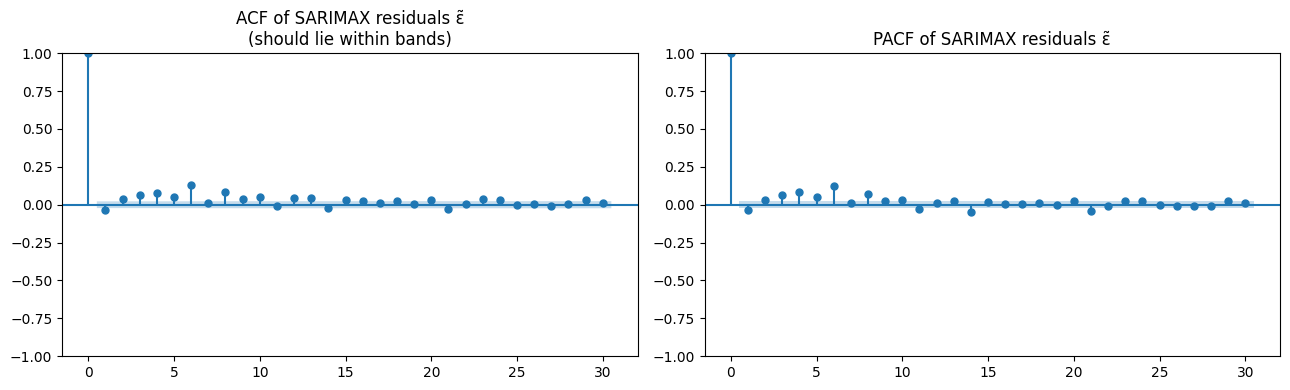

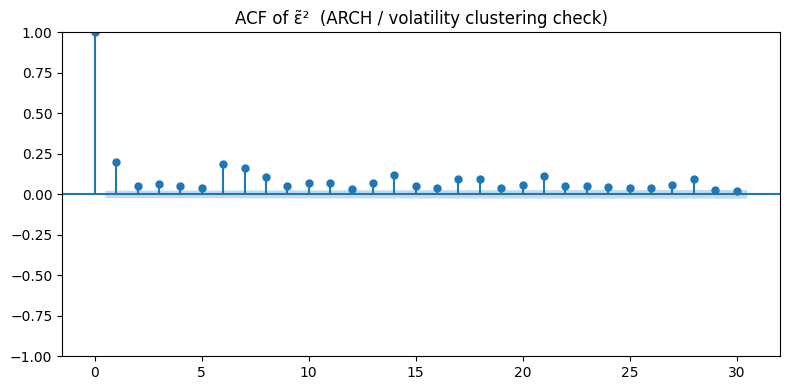

In [ ]:
#  Autocorrelation diagnostics
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step R3: Autocorrelation diagnostics ─────────────────────────")
 
lb = acorr_ljungbox(eps_sarimax, lags=[1, 5, 7, 10, 14, 21], return_df=True)
print(f"  Ljung-Box on ε̃:")
for lag, row in lb.iterrows():
    sig = "✓" if row["lb_pvalue"] > 0.05 else "✗"
    print(f"    lag={lag:2d}  p={row['lb_pvalue']:.4f}  {sig}")
 
arch_stat, arch_p, _, _ = het_arch(eps_sarimax, nlags=5)
print(f"\n  ARCH-LM on ε̃:")
print(f"    stat={arch_stat:.3f}  p={arch_p:.4f}  "
      f"{'✓ no ARCH' if arch_p > 0.05 else '✗ ARCH present (noted as limitation)'}")
 
# ACF / PACF plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( eps_sarimax, lags=30, ax=axes[0])
axes[0].set_title("ACF of SARIMAX residuals ε̃\n"
                  "(should lie within bands)")
plot_pacf(eps_sarimax, lags=30, ax=axes[1])
axes[1].set_title("PACF of SARIMAX residuals ε̃")
plt.tight_layout()
plt.show()
 
# ACF of ε̃² — ARCH check
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(eps_sarimax**2, lags=30, ax=ax)
ax.set_title("ACF of ε̃²  (ARCH / volatility clustering check)")
plt.tight_layout()
plt.show()